In [1]:
#imports

import os
import pandas as pd
import numpy as np
import biom
from qiime2 import Metadata, Artifact
from skbio.stats.composition import clr_inv as softmax
from skbio.stats.composition import clr
from qiime2.plugins.gemelli.actions import (joint_rpca, filter_ordination, feature_correlation_table)
from qiime2.plugins.longitudinal.actions import volatility

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
%matplotlib inline



# Import necessary ml libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import umap
import shap
import os
import time

import pandas as pd
# import qupid
import os

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.stats import kruskal
from scipy.stats import mannwhitneyu

# qiime2 imports
import qiime2 as q2
from qiime2 import Artifact, Metadata, Visualization
from qiime2.plugins.feature_table.methods import filter_features, filter_samples
import qiime2.plugins.diversity.actions as diversity_actions


# birdman imports
import biom
import numpy as np


In [2]:
# load data
table_metag = biom.load_table('data/metaG/222424_72996_analysis_Metagenomic_Woltkav014DatabasescratchqpwoltkaWoLr2WoLr2BIOMnonebiom.biom')
table_metag_df = table_metag.to_dataframe().T
table_metaT = biom.load_table('data/metaT/222425_72996_analysis_Metatranscriptomic_Woltkav014DatabasescratchqpwoltkaWoLr2WoLr2BIOMnonebiom.biom')
table_metaT_df = table_metaT.to_dataframe().T
metadata = Metadata.load('data/metadata/72996_72996_analysis_mapping.txt')
metadata = metadata.to_dataframe()
taxonomy = pd.read_csv("data/lineages.txt", sep='\t', header=None)
phylogeny = Artifact.import_data("Phylogeny[Rooted]", "data/tree.nwk")



In [3]:
table_metag_df

,G000005825,G000006605,G000006725,G000006745,G000006785,G000006845,G000006865,G000006925,G000006965,G000006985,...,G902810735,G902812325,G902812365,G902812395,G902825795,G902825845,G902825965,G902826025,G902826465,G902827055
11484.CSM5FZ3N,0.0,0.0,0.0,0.0,4.0,0.0,68.0,142.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11484.CSM5FZ3R,0.0,0.0,0.0,0.0,1.0,8.0,106.0,142.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11484.CSM5FZ3T,0.0,0.0,0.0,0.0,0.0,1.0,0.0,8.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0
11484.CSM5FZ3V,0.0,0.0,0.0,0.0,0.0,0.0,18.0,924.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11484.CSM5FZ3X,0.0,0.0,0.0,1.0,1.0,1.0,1.0,17126.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11484.PSMB4MBS,1.0,0.0,0.0,0.0,0.0,0.0,1.0,157.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11484.PSMB4MC1,1.0,0.0,0.0,0.0,0.0,1.0,68.0,1743.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11484.PSMB4MC3,0.0,0.0,0.0,0.0,0.0,0.0,8.0,13.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11484.PSMB4MC5,1.0,0.0,0.0,0.0,1.0,1.0,0.0,28.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
table_metaT_df

,G000006865,G000006925,G000007145,G000007265,G000007325,G000007525,G000007645,G000007745,G000007785,G000007805,...,G902790745,G902790905,G902790955,G902792045,G902794445,G902798155,G902799415,G902799635,G902800075,G902801355
11484.ESM718TF,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11484.ESM718T7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11484.PSM7J177,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11484.PSM7J179,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11484.MSM6J2K6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11484.HSMA33P6,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11484.HSMA33J3,0.0,10.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11484.HSMA33PL,1.0,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11484.HSMA33J5,0.0,1.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
print(metadata.columns.tolist())


['run_prefix', 'runid', 'experiment_design_description', 'library_construction_protocol', 'run_center', 'run_date', 'instrument_model', 'center_project_name', 'sequencing_meth', 'platform', 'has_subject_undergone_any_girelated_radiology_procedures', 'i_felt_helpless', 'xifaxin_rifaxamin', 'flagyl_metronidazole', 'were_you_hospitalized_before_the_age_of_five', 'has_the_subject_been_given_new_stool_kits', 'race', 'reason_for_stopping_other_antibiotic', 'in_the_past_6_months_have_you_used_antibiotics', 'diet_soft_drinks_tea_or_coffee_with_sugar_stevia_equal_splenda_', 'diagnosis', 'scanned_ffqyaq_document', 'week_num', 'tube_a_and_b_received_at_broad', 'rectum_cell_biopsy', 'noninflamed_dnarna', 'i_had_a_problem_with_my_sleep', 'please_list_your_current_hormonal_contraceptive', 'male_distant_relative_2', 'i_felt_that_i_had_nothing_to_look_forward_to', 'were_you_born_in_a_hospital', 'site_name', 'i_was_satisfied_with_my_sleep', 'water', 'highest_dose_of_entocort_taken_mg', 'bmi', 'dna_extr

In [6]:
metadata["diagnosis"].value_counts()

CD        735
UC        444
nonIBD    413
Name: diagnosis, dtype: int64

In [7]:
lineages = pd.read_csv('data/lineages.txt', sep='\t', header=None)
lineages.columns = ['genome_id', 'taxonomy']

# Check the format
print("Lineages file format:")
print(lineages.head())
print(f"Total genomes: {len(lineages)}")

# Get your feature IDs
metag_features = list(table_metag_df.columns)
metaT_features = list(table_metaT_df.columns)

# Filter for your features
metag_taxonomy = lineages[lineages['genome_id'].isin(metag_features)]
metaT_taxonomy = lineages[lineages['genome_id'].isin(metaT_features)]

print(f"\nMetagenomic features with taxonomy: {len(metag_taxonomy)}")
print(f"Metatranscriptomic features with taxonomy: {len(metaT_taxonomy)}")

# Save taxonomy files in QIIME2 format (feature_id \t taxonomy)
metag_taxonomy.to_csv('data/metaG/metag_taxonomy.tsv', sep='\t', index=False, header=False)
metaT_taxonomy.to_csv('data/metaT/metaT_taxonomy.tsv', sep='\t', index=False, header=False)

# Check a few examples
print("\nSample taxonomy mappings:")
print(metag_taxonomy.head())

Lineages file format:
    genome_id                                           taxonomy
0  G000005825  d__Bacteria; p__Firmicutes; c__Bacilli; o__Bac...
1  G000006175  d__Archaea; p__Methanobacteriota_A; c__Methano...
2  G000006605  d__Bacteria; p__Actinobacteriota; c__Actinomyc...
3  G000006725  d__Bacteria; p__Proteobacteria; c__Gammaproteo...
4  G000006745  d__Bacteria; p__Proteobacteria; c__Gammaproteo...
Total genomes: 15953

Metagenomic features with taxonomy: 10616
Metatranscriptomic features with taxonomy: 2111

Sample taxonomy mappings:
    genome_id                                           taxonomy
0  G000005825  d__Bacteria; p__Firmicutes; c__Bacilli; o__Bac...
2  G000006605  d__Bacteria; p__Actinobacteriota; c__Actinomyc...
3  G000006725  d__Bacteria; p__Proteobacteria; c__Gammaproteo...
4  G000006745  d__Bacteria; p__Proteobacteria; c__Gammaproteo...
5  G000006785  d__Bacteria; p__Firmicutes; c__Bacilli; o__Lac...


In [8]:
metag_taxonomy

,genome_id,taxonomy
0,G000005825,d__Bacteria; p__Firmicutes; c__Bacilli; o__Bac...
2,G000006605,d__Bacteria; p__Actinobacteriota; c__Actinomyc...
3,G000006725,d__Bacteria; p__Proteobacteria; c__Gammaproteo...
4,G000006745,d__Bacteria; p__Proteobacteria; c__Gammaproteo...
5,G000006785,d__Bacteria; p__Firmicutes; c__Bacilli; o__Lac...
...,...,...
15946,G902825845,d__Bacteria; p__Proteobacteria; c__Gammaproteo...
15947,G902825965,d__Bacteria; p__Gemmatimonadota; c__Gemmatimon...
15948,G902826025,d__Bacteria; p__Actinobacteriota; c__Acidimicr...
15949,G902826465,d__Bacteria; p__Acidobacteriota; c__Vicinamiba...


In [9]:
metaT_taxonomy

,genome_id,taxonomy
7,G000006865,d__Bacteria; p__Firmicutes; c__Bacilli; o__Lac...
8,G000006925,d__Bacteria; p__Proteobacteria; c__Gammaproteo...
15,G000007145,d__Bacteria; p__Proteobacteria; c__Gammaproteo...
19,G000007265,d__Bacteria; p__Firmicutes; c__Bacilli; o__Lac...
21,G000007325,d__Bacteria; p__Fusobacteriota; c__Fusobacteri...
...,...,...
15908,G902798155,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...
15917,G902799415,d__Bacteria; p__Firmicutes_A; c__Clostridia; o...
15918,G902799635,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...
15921,G902800075,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...


# rarefaction curves

In [11]:
# Analyze depth distributions to choose smart rarefaction parameters
import numpy as np
import pandas as pd

print("=== DEPTH ANALYSIS FOR SMART RAREFACTION ===")

# Get depth statistics
metag_depths = table_metag_df.sum(axis=1)
metaT_depths = table_metaT_df.sum(axis=1)

print(f"\nMetagenomic depth statistics:")
print(f"Min depth: {metag_depths.min():,.0f}")
print(f"10th percentile: {metag_depths.quantile(0.1):,.0f}")
print(f"25th percentile: {metag_depths.quantile(0.25):,.0f}")
print(f"Median: {metag_depths.median():,.0f}")
print(f"75th percentile: {metag_depths.quantile(0.75):,.0f}")
print(f"Max depth: {metag_depths.max():,.0f}")

print(f"\nMetatranscriptomic depth statistics:")
print(f"Min depth: {metaT_depths.min():,.0f}")
print(f"10th percentile: {metaT_depths.quantile(0.1):,.0f}")
print(f"25th percentile: {metaT_depths.quantile(0.25):,.0f}")
print(f"Median: {metaT_depths.median():,.0f}")
print(f"75th percentile: {metaT_depths.quantile(0.75):,.0f}")
print(f"Max depth: {metaT_depths.max():,.0f}")

# Sample 10% of data for rarefaction curves (150 samples instead of 1500)
np.random.seed(42)
metag_sample_indices = np.random.choice(metag_depths.index, size=int(len(metag_depths) * 0.1), replace=False)
metaT_sample_indices = np.random.choice(metaT_depths.index, size=int(len(metaT_depths) * 0.1), replace=False)

# Create subsampled tables
metag_sampled = table_metag_df.loc[metag_sample_indices]
metaT_sampled = table_metaT_df.loc[metaT_sample_indices]

print(f"\nSubsampled for rarefaction analysis:")
print(f"Metagenomic: {len(metag_sampled)} samples (10% of {len(table_metag_df)})")
print(f"Metatranscriptomic: {len(metaT_sampled)} samples (10% of {len(table_metaT_df)})")

# Check if 50k depth makes sense
target_depth_metag = 50000
target_depth_metaT = min(50000, int(metaT_depths.quantile(0.9)))  # Don't go above 90th percentile for metaT

metag_retained_50k = (metag_depths >= target_depth_metag).sum()
metag_pct_retained_50k = (metag_retained_50k / len(metag_depths)) * 100

metaT_retained_target = (metaT_depths >= target_depth_metaT).sum()
metaT_pct_retained_target = (metaT_retained_target / len(metaT_depths)) * 100

print(f"\n=== RAREFACTION DEPTH RECOMMENDATIONS ===")
print(f"\nMetagenomic at {target_depth_metag:,} reads:")
print(f"  Samples retained: {metag_retained_50k}/{len(metag_depths)} ({metag_pct_retained_50k:.1f}%)")

print(f"\nMetatranscriptomic at {target_depth_metaT:,} reads:")
print(f"  Samples retained: {metaT_retained_target}/{len(metaT_depths)} ({metaT_pct_retained_target:.1f}%)")

# Suggest alternative depths if 50k drops too many samples
if metag_pct_retained_50k < 80:
    alt_depth_metag = int(metag_depths.quantile(0.2))  # 20th percentile = 80% retention
    alt_retained = (metag_depths >= alt_depth_metag).sum()
    alt_pct = (alt_retained / len(metag_depths)) * 100
    print(f"\nAlternative metagenomic depth: {alt_depth_metag:,} reads -> {alt_retained} samples ({alt_pct:.1f}%)")

if metaT_pct_retained_target < 80:
    alt_depth_metaT = int(metaT_depths.quantile(0.2))  # 20th percentile = 80% retention
    alt_retained_T = (metaT_depths >= alt_depth_metaT).sum()
    alt_pct_T = (alt_retained_T / len(metaT_depths)) * 100
    print(f"\nAlternative metatranscriptomic depth: {alt_depth_metaT:,} reads -> {alt_retained_T} samples ({alt_pct_T:.1f}%)")

# Create biom tables from subsampled data
from biom import Table

print(f"\n=== CREATING SUBSAMPLED ARTIFACTS FOR RAREFACTION ===")

# Create subsampled biom tables
metag_sampled_biom = Table(metag_sampled.values.T, 
                          observation_ids=metag_sampled.columns,
                          sample_ids=metag_sampled.index)

metaT_sampled_biom = Table(metaT_sampled.values.T,
                          observation_ids=metaT_sampled.columns, 
                          sample_ids=metaT_sampled.index)

# Convert to QIIME2 artifacts
metag_sampled_artifact = Artifact.import_data('FeatureTable[Frequency]', metag_sampled_biom)
metaT_sampled_artifact = Artifact.import_data('FeatureTable[Frequency]', metaT_sampled_biom)

print("Subsampled artifacts created successfully!")

# Use recommended depths (or 50k if retention is good)
final_depth_metag = target_depth_metag if metag_pct_retained_50k >= 80 else int(metag_depths.quantile(0.2))
final_depth_metaT = target_depth_metaT if metaT_pct_retained_target >= 80 else int(metaT_depths.quantile(0.2))

print(f"\nFinal rarefaction depths:")
print(f"Metagenomic: {final_depth_metag:,} reads")
print(f"Metatranscriptomic: {final_depth_metaT:,} reads")

# Store these for the rarefaction analysis
print(f"\nReady for fast rarefaction analysis with 10% subsampled data!")

=== DEPTH ANALYSIS FOR SMART RAREFACTION ===

Metagenomic depth statistics:
Min depth: 199
10th percentile: 2,452,582
25th percentile: 4,447,422
Median: 6,466,349
75th percentile: 8,645,721
Max depth: 36,304,201

Metatranscriptomic depth statistics:
Min depth: 2
10th percentile: 3,836
25th percentile: 7,902
Median: 12,804
75th percentile: 20,519
Max depth: 100,242

Subsampled for rarefaction analysis:
Metagenomic: 159 samples (10% of 1592)
Metatranscriptomic: 74 samples (10% of 741)

=== RAREFACTION DEPTH RECOMMENDATIONS ===

Metagenomic at 50,000 reads:
  Samples retained: 1577/1592 (99.1%)

Metatranscriptomic at 30,752 reads:
  Samples retained: 75/741 (10.1%)

Alternative metatranscriptomic depth: 6,599 reads -> 593 samples (80.0%)

=== CREATING SUBSAMPLED ARTIFACTS FOR RAREFACTION ===
Subsampled artifacts created successfully!

Final rarefaction depths:
Metagenomic: 50,000 reads
Metatranscriptomic: 6,599 reads

Ready for fast rarefaction analysis with 10% subsampled data!


In [13]:
# Run fast rarefaction analysis on subsampled data
import qiime2.plugins.diversity.actions as diversity_actions
from qiime2 import Metadata

print("=== RUNNING FAST RAREFACTION ANALYSIS ===")
print("Using subsampled data: 159 metagenomic + 74 metatranscriptomic samples")

# Create separate metadata for each dataset to avoid duplicate IDs
metadata_metag_sampled = metadata.loc[metag_sample_indices]
metadata_metaT_sampled = metadata.loc[metaT_sample_indices]

metadata_metag_q2 = Metadata(metadata_metag_sampled)
metadata_metaT_q2 = Metadata(metadata_metaT_sampled)

print("\nGenerating metagenomic rarefaction curves...")
try:
    metag_rarefaction = diversity_actions.alpha_rarefaction(
        table=metag_sampled_artifact,
        max_depth=50000,  # Target depth
        min_depth=10000,  # Start at 10k to save computation
        steps=5,
        metadata=metadata_metag_q2
        # No phylogeny = fast computation
    )
    
    metag_rarefaction.visualization.save('metag_rarefaction_subsampled.qzv')
    print("✓ Metagenomic rarefaction curves completed!")
    
except Exception as e:
    print(f"✗ Error in metagenomic rarefaction: {e}")

print("\nGenerating metatranscriptomic rarefaction curves...")
try:
    metaT_rarefaction = diversity_actions.alpha_rarefaction(
        table=metaT_sampled_artifact,
        max_depth=6599,   # Recommended depth for 80% retention
        min_depth=1000,   # Start at 1k
        steps=5,
        metadata=metadata_metaT_q2
        # No phylogeny = fast computation
    )
    
    metaT_rarefaction.visualization.save('metaT_rarefaction_subsampled.qzv')
    print("✓ Metatranscriptomic rarefaction curves completed!")
    
except Exception as e:
    print(f"✗ Error in metatranscriptomic rarefaction: {e}")

print("\n=== RESULTS ===")
print("Rarefaction curve files saved:")
print("- metag_rarefaction_subsampled.qzv")
print("- metaT_rarefaction_subsampled.qzv")
print("\nView with: qiime tools view filename.qzv")

print("\n=== FINAL RECOMMENDATIONS ===")
print("Based on this analysis, use these rarefaction depths for your full dataset:")
print(f"• Metagenomic: 50,000 reads (retains 99.1% of samples)")
print(f"• Metatranscriptomic: 6,599 reads (retains 80.0% of samples)")

print(f"\nTo rarefy your full datasets:")
print("# Metagenomic rarefaction")
print("from qiime2.plugins.feature_table.methods import rarefy")
print("metag_rarefied = rarefy(table=metag_artifact, sampling_depth=50000)")

print("\n# Metatranscriptomic rarefaction") 
print("metaT_rarefied = rarefy(table=metaT_artifact, sampling_depth=6599)")

print(f"\nThis will give you:")
print(f"• Metagenomic: {1577} samples rarefied to 50,000 reads each")
print(f"• Metatranscriptomic: {593} samples rarefied to 6,599 reads each")

=== RUNNING FAST RAREFACTION ANALYSIS ===
Using subsampled data: 159 metagenomic + 74 metatranscriptomic samples

Generating metagenomic rarefaction curves...


The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric

✓ Metagenomic rarefaction curves completed!

Generating metatranscriptomic rarefaction curves...


The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric

✓ Metatranscriptomic rarefaction curves completed!

=== RESULTS ===
Rarefaction curve files saved:
- metag_rarefaction_subsampled.qzv
- metaT_rarefaction_subsampled.qzv

View with: qiime tools view filename.qzv

=== FINAL RECOMMENDATIONS ===
Based on this analysis, use these rarefaction depths for your full dataset:
• Metagenomic: 50,000 reads (retains 99.1% of samples)
• Metatranscriptomic: 6,599 reads (retains 80.0% of samples)

To rarefy your full datasets:
# Metagenomic rarefaction
from qiime2.plugins.feature_table.methods import rarefy
metag_rarefied = rarefy(table=metag_artifact, sampling_depth=50000)

# Metatranscriptomic rarefaction
metaT_rarefied = rarefy(table=metaT_artifact, sampling_depth=6599)

This will give you:
• Metagenomic: 1577 samples rarefied to 50,000 reads each
• Metatranscriptomic: 593 samples rarefied to 6,599 reads each


In [18]:
# Calculate sample retention at different depths
depths_to_test = [50000, 55000, 60000, 65000]
metag_depths = table_metag_df.sum(axis=1)

for depth in depths_to_test:
    retained = (metag_depths >= depth).sum()
    pct = (retained / len(metag_depths)) * 100
    lost = len(metag_depths) - retained
    print(f"Metagenomic {depth:,}: {retained} samples ({pct:.1f}%) - lose {lost} samples")

depths_to_test_T = [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6599, 7000, 7500, 8000]
metaT_depths = table_metaT_df.sum(axis=1)

for depth in depths_to_test_T:
    retained = (metaT_depths >= depth).sum()
    pct = (retained / len(metaT_depths)) * 100
    lost = len(metaT_depths) - retained
    print(f"Metatranscriptomic {depth:,}: {retained} samples ({pct:.1f}%) - lose {lost} samples")

Metagenomic 50,000: 1577 samples (99.1%) - lose 15 samples
Metagenomic 55,000: 1577 samples (99.1%) - lose 15 samples
Metagenomic 60,000: 1576 samples (99.0%) - lose 16 samples
Metagenomic 65,000: 1575 samples (98.9%) - lose 17 samples
Metatranscriptomic 500: 729 samples (98.4%) - lose 12 samples
Metatranscriptomic 1,000: 719 samples (97.0%) - lose 22 samples
Metatranscriptomic 1,500: 710 samples (95.8%) - lose 31 samples
Metatranscriptomic 2,000: 709 samples (95.7%) - lose 32 samples
Metatranscriptomic 2,500: 697 samples (94.1%) - lose 44 samples
Metatranscriptomic 3,000: 689 samples (93.0%) - lose 52 samples
Metatranscriptomic 3,500: 675 samples (91.1%) - lose 66 samples
Metatranscriptomic 4,000: 664 samples (89.6%) - lose 77 samples
Metatranscriptomic 4,500: 655 samples (88.4%) - lose 86 samples
Metatranscriptomic 5,000: 645 samples (87.0%) - lose 96 samples
Metatranscriptomic 5,500: 629 samples (84.9%) - lose 112 samples
Metatranscriptomic 6,000: 615 samples (83.0%) - lose 126 samp

In [10]:
# Import the correct function from gemelli
from gemelli.preprocessing import matrix_rclr
import pandas as pd

# Apply robust CLR transformation from gemelli to the biom tables
# For metagenomic data
table_metag_array = table_metag.matrix_data.toarray().T  # Convert biom to dense array and transpose
table_metag_rclr = pd.DataFrame(
    matrix_rclr(table_metag_array),
    index=table_metag.ids('sample'),
    columns=table_metag.ids('observation')
)

# For metatrancriptomics data
table_metaT_array = table_metaT.matrix_data.toarray().T  # Convert biom to dense array and transpose
table_metaT_rclr = pd.DataFrame(
    matrix_rclr(table_metaT_array),
    index=table_metaT.ids('sample'),
    columns=table_metaT.ids('observation')
)

print(f"MetaG RCLR shape: {table_metag_rclr.shape}")
print(f"MetaT RCLR shape: {table_metaT_rclr.shape}")

MetaG RCLR shape: (1592, 10616)
MetaT RCLR shape: (741, 2111)


In [42]:
# Remove features (columns) that are mostly zeros
min_prevalence = 0.3  # Present in at least 10% of samples
prevalence = (table_metag_array > 0).mean(axis=0)
keep_features = prevalence >= min_prevalence

table_metag_filtered = table_metag_array[:, keep_features]
table_metag_rclr_filtered = pd.DataFrame(
    matrix_rclr(table_metag_filtered),
    index=table_metag.ids('sample'),
    columns=[table_metag.ids('observation')[i] for i in range(len(keep_features)) if keep_features[i]]
)

In [39]:
table_metag_rclr_filtered

,G000005825,G000006605,G000006745,G000006785,G000006845,G000006865,G000006925,G000007145,G000007265,G000007325,...,G902798845,G902798855,G902799415,G902799635,G902800075,G902800385,G902801355,G902801975,G902802355,G902810735
11484.CSM5FZ3N,NaN,NaN,NaN,-1.554000,NaN,1.279213,2.015532,NaN,2.604883,NaN,...,NaN,NaN,-0.455388,NaN,-2.247147,NaN,-2.940295,NaN,NaN,NaN
11484.CSM5FZ3R,NaN,NaN,NaN,-2.759473,-0.680031,1.903966,2.196354,NaN,0.073740,-2.759473,...,NaN,NaN,-0.361578,NaN,-1.660861,NaN,-2.759473,NaN,NaN,NaN
11484.CSM5FZ3T,NaN,NaN,NaN,NaN,-2.574575,NaN,-0.495134,NaN,NaN,-2.574575,...,NaN,NaN,-1.881428,NaN,-1.881428,NaN,NaN,NaN,NaN,NaN
11484.CSM5FZ3V,NaN,NaN,NaN,NaN,NaN,0.093828,4.032168,NaN,-1.697932,NaN,...,NaN,-2.796544,-0.311638,NaN,-1.410250,NaN,-2.796544,NaN,NaN,-2.796544
11484.CSM5FZ3X,NaN,NaN,-2.523215,-2.523215,-2.523215,-2.523215,7.225138,-1.136920,-0.731455,NaN,...,NaN,NaN,-0.731455,NaN,-2.523215,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11484.PSMB4MBS,-3.039970,NaN,NaN,NaN,NaN,-3.039970,2.016276,NaN,-0.206756,-0.737385,...,-3.039970,-1.653675,0.831231,-3.039970,-3.039970,-3.039970,-3.039970,NaN,-3.03997,NaN
11484.PSMB4MC1,-2.646579,NaN,NaN,NaN,-2.646579,1.572928,4.816784,-1.953432,-1.953432,-2.646579,...,NaN,NaN,0.649257,-2.646579,-2.646579,-2.646579,-1.953432,NaN,NaN,NaN
11484.PSMB4MC3,NaN,NaN,NaN,NaN,NaN,-0.578277,-0.092769,-0.865959,NaN,NaN,...,NaN,NaN,-0.355134,NaN,-2.657719,NaN,NaN,NaN,NaN,NaN
11484.PSMB4MC5,-2.836447,NaN,NaN,-2.836447,-2.836447,NaN,0.495757,NaN,-2.836447,0.689913,...,NaN,NaN,-0.003234,NaN,NaN,NaN,-2.836447,NaN,NaN,NaN


In [40]:
# Remove features (columns) that are mostly zeros
min_prevalence = 0.3  # Present in at least 10% of samples
prevalence = (table_metag_array > 0).mean(axis=0)
keep_features = prevalence >= min_prevalence

table_metag_filtered = table_metag_array[:, keep_features]


pseudocount = 1e-6
table_metag_array_pseudo = table_metag_filtered + pseudocount

table_metag_rclr_psuedo_filtered = pd.DataFrame(
    matrix_rclr(table_metag_array_pseudo),
    index=table_metag.ids('sample'),
    columns=[table_metag.ids('observation')[i] for i in range(len(keep_features)) if keep_features[i]]
)

In [41]:
table_metag_rclr_psuedo_filtered

,G000005825,G000006785,G000006845,G000006865,G000006925,G000007145,G000007265,G000007325,G000007465,G000007525,...,G902798155,G902798535,G902798655,G902798725,G902798845,G902799415,G902799635,G902800075,G902800385,G902801355
11484.CSM5FZ3N,-11.873552,3.328253,-11.873552,6.161466,6.897785,-11.873552,7.487136,-11.873552,1.941959,1.941959,...,4.139183,4.581016,4.832330,-11.873552,-11.873552,4.426865,-11.873552,2.635106,-11.873552,1.941959
11484.CSM5FZ3R,-13.031411,0.784100,2.863541,5.447538,5.739926,-13.031411,3.617313,0.784100,0.784100,8.939748,...,3.181995,3.086684,4.042196,-13.031411,-13.031411,3.181995,-13.031411,1.882712,-13.031411,0.784100
11484.CSM5FZ3T,-10.877921,-10.877921,2.937590,-10.877921,5.017031,-10.877921,-10.877921,2.937590,-10.877921,7.850244,...,4.547028,6.338787,5.134814,-10.877921,-10.877921,3.630737,-10.877921,3.630737,-10.877921,-10.877921
11484.CSM5FZ3V,-12.531152,-12.531152,-12.531152,4.174730,8.113071,-12.531152,2.382971,-12.531152,-12.531152,-12.531152,...,4.056947,2.893797,4.542455,-12.531152,-12.531152,3.769265,-12.531152,2.670653,-12.531152,1.284360
11484.CSM5FZ3X,-12.553883,1.261628,1.261628,1.261628,11.009980,2.647922,3.053387,-12.553883,-12.553883,6.632265,...,2.871065,2.871065,3.564212,-12.553883,-12.553883,3.053387,-12.553883,1.261628,-12.553883,-12.553883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11484.PSMB4MBS,0.595535,-13.219977,-13.219977,0.595535,5.651780,-13.219977,3.428747,2.898119,0.595535,9.080823,...,1.288681,2.674975,2.898119,-13.219977,0.595535,4.466735,0.595535,0.595535,0.595535,0.595535
11484.PSMB4MC1,-0.755246,-14.570758,-0.755246,3.464260,6.708116,-0.062100,-0.062100,-0.755246,-14.570758,7.646311,...,1.036512,1.036512,-14.570758,-0.755246,-14.570758,2.540590,-0.755246,-0.755246,-0.755246,-0.062100
11484.PSMB4MC3,-10.568804,-10.568804,-10.568804,5.326149,5.811656,5.038467,-10.568804,-10.568804,-10.568804,9.638624,...,4.345320,3.246708,-10.568804,-10.568804,-10.568804,5.549292,-10.568804,3.246708,-10.568804,-10.568804
11484.PSMB4MC5,1.987697,1.987697,1.987697,-11.827815,5.319900,-11.827815,1.987697,5.514056,-11.827815,10.290209,...,2.680843,3.373990,-11.827815,-11.827815,-11.827815,4.820909,-11.827815,-11.827815,-11.827815,1.987697


In [32]:
# Add a small pseudocount to avoid zeros
pseudocount = 1e-6
table_metag_array_pseudo = table_metag_array + pseudocount

table_metag_rclr_psuedo = pd.DataFrame(
    matrix_rclr(table_metag_array_pseudo),
    index=table_metag.ids('sample'),
    columns=table_metag.ids('observation')
)

In [33]:
table_metag_rclr_psuedo

,G000005825,G000006605,G000006725,G000006745,G000006785,G000006845,G000006865,G000006925,G000006965,G000006985,...,G902810735,G902812325,G902812365,G902812395,G902825795,G902825845,G902825965,G902826025,G902826465,G902827055
11484.CSM5FZ3N,-3.137117,-3.137117,-3.137117,-3.137117,12.064688,-3.137117,14.897901,15.634221,-3.137117,-3.137117,...,-3.137117,-3.137117,-3.137117,-3.137117,-3.137117,-3.137117,-3.137117,-3.137117,-3.137117,-3.137117
11484.CSM5FZ3R,-3.688906,-3.688906,-3.688906,-3.688906,10.126606,12.206047,14.790044,15.082432,-3.688906,-3.688906,...,-3.688906,-3.688906,-3.688906,-3.688906,-3.688906,-3.688906,-3.688906,-3.688906,-3.688906,-3.688906
11484.CSM5FZ3T,-3.176407,-3.176407,-3.176407,-3.176407,-3.176407,10.639104,-3.176407,12.718545,-3.176407,-3.176407,...,-3.176407,-3.176407,-3.176407,-3.176407,-3.176407,12.430863,-3.176407,-3.176407,-3.176407,-3.176407
11484.CSM5FZ3V,-3.644329,-3.644329,-3.644329,-3.644329,-3.644329,-3.644329,13.061553,16.999893,-3.644329,-3.644329,...,10.171182,-3.644329,-3.644329,-3.644329,-3.644329,-3.644329,-3.644329,-3.644329,-3.644329,-3.644329
11484.CSM5FZ3X,-3.958668,-3.958668,-3.958668,9.856843,9.856843,9.856843,9.856843,19.605195,-3.958668,-3.958668,...,-3.958668,-3.958668,-3.958668,-3.958668,-3.958668,11.936284,-3.958668,-3.958668,10.549990,-3.958668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11484.PSMB4MBS,10.362874,-3.452637,-3.452637,-3.452637,-3.452637,-3.452637,10.362874,15.419119,-3.452637,-3.452637,...,-3.452637,-3.452637,-3.452637,-3.452637,-3.452637,-3.452637,-3.452637,-3.452637,-3.452637,-3.452637
11484.PSMB4MC1,9.681192,-4.134319,-4.134319,-4.134319,-4.134319,9.681192,13.900699,17.144554,-4.134319,-4.134319,...,-4.134319,-4.134319,-4.134319,-4.134319,-4.134319,-4.134319,-4.134319,-4.134319,-4.134319,-4.134319
11484.PSMB4MC3,-2.704220,-2.704220,-2.704220,-2.704220,-2.704220,-2.704220,13.190732,13.676240,-2.704220,-2.704220,...,-2.704220,-2.704220,-2.704220,-2.704220,-2.704220,-2.704220,-2.704220,-2.704220,-2.704220,-2.704220
11484.PSMB4MC5,10.692474,-3.123038,-3.123038,-3.123038,10.692474,10.692474,-3.123038,14.024678,-3.123038,-3.123038,...,-3.123038,-3.123038,-3.123038,-3.123038,-3.123038,-3.123038,-3.123038,-3.123038,-3.123038,-3.123038


In [18]:
table_metag_df

,G000005825,G000006605,G000006725,G000006745,G000006785,G000006845,G000006865,G000006925,G000006965,G000006985,...,G902810735,G902812325,G902812365,G902812395,G902825795,G902825845,G902825965,G902826025,G902826465,G902827055
11484.CSM5FZ3N,0.0,0.0,0.0,0.0,4.0,0.0,68.0,142.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11484.CSM5FZ3R,0.0,0.0,0.0,0.0,1.0,8.0,106.0,142.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11484.CSM5FZ3T,0.0,0.0,0.0,0.0,0.0,1.0,0.0,8.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0
11484.CSM5FZ3V,0.0,0.0,0.0,0.0,0.0,0.0,18.0,924.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11484.CSM5FZ3X,0.0,0.0,0.0,1.0,1.0,1.0,1.0,17126.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11484.PSMB4MBS,1.0,0.0,0.0,0.0,0.0,0.0,1.0,157.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11484.PSMB4MC1,1.0,0.0,0.0,0.0,0.0,1.0,68.0,1743.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11484.PSMB4MC3,0.0,0.0,0.0,0.0,0.0,0.0,8.0,13.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11484.PSMB4MC5,1.0,0.0,0.0,0.0,1.0,1.0,0.0,28.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
table_metag_rclr

,G000005825,G000006605,G000006725,G000006745,G000006785,G000006845,G000006865,G000006925,G000006965,G000006985,...,G902810735,G902812325,G902812365,G902812395,G902825795,G902825845,G902825965,G902826025,G902826465,G902827055
11484.CSM5FZ3N,NaN,NaN,NaN,NaN,-1.508497,NaN,1.324716,2.061035,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11484.CSM5FZ3R,NaN,NaN,NaN,NaN,-2.680454,-0.601013,1.982985,2.275373,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11484.CSM5FZ3T,NaN,NaN,NaN,NaN,NaN,-2.451126,NaN,-0.371685,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.659367,NaN,NaN,NaN,NaN
11484.CSM5FZ3V,NaN,NaN,NaN,NaN,NaN,NaN,0.221776,4.160116,NaN,NaN,...,-2.668596,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11484.CSM5FZ3X,NaN,NaN,NaN,-2.335612,-2.335612,-2.335612,-2.335612,7.412741,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.256170,NaN,NaN,-1.642464,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11484.PSMB4MBS,-2.982471,NaN,NaN,NaN,NaN,NaN,-2.982471,2.073774,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11484.PSMB4MC1,-2.543017,NaN,NaN,NaN,NaN,-2.543017,1.676490,4.920346,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11484.PSMB4MC3,NaN,NaN,NaN,NaN,NaN,NaN,-0.556623,-0.071115,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11484.PSMB4MC5,-2.794793,NaN,NaN,NaN,-2.794793,-2.794793,NaN,0.537412,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
table_metaT_rclr

,G000006865,G000006925,G000007145,G000007265,G000007325,G000007525,G000007645,G000007745,G000007785,G000007805,...,G902790745,G902790905,G902790955,G902792045,G902794445,G902798155,G902799415,G902799635,G902800075,G902801355
11484.ESM718TF,NaN,-1.190655,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11484.ESM718T7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11484.PSM7J177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11484.PSM7J179,NaN,NaN,NaN,NaN,NaN,NaN,-0.217289,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11484.MSM6J2K6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11484.HSMA33P6,NaN,NaN,NaN,NaN,NaN,-1.126520,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11484.HSMA33J3,NaN,0.686110,NaN,NaN,NaN,-0.923328,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11484.HSMA33PL,-1.512244,0.097194,NaN,NaN,NaN,-1.512244,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11484.HSMA33J5,NaN,-1.344043,NaN,NaN,NaN,-0.650896,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
# Microbiome IBD Classification Pipeline with VAE+SAE Feature Engineering
# Adapted for metagenomics and metatranscriptomics data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import umap
import biom
from qiime2 import Metadata
from gemelli.preprocessing import matrix_rclr
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# =============================================================================
# 1. HELPER FUNCTIONS
# =============================================================================

def get_device():
    """Get the appropriate device for computation"""
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using MPS (Metal Performance Shaders) device")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print("Using CUDA device")
    else:
        device = torch.device("cpu")
        print("Using CPU device")
    return device

def add_noise(data, noise_factor=0.05):
    """Add noise to input data for regularization"""
    noise = torch.randn_like(data) * noise_factor * data.std()
    return data + noise

def plot_training_curves(train_losses, val_losses, title="Training Curves"):
    """Plot training and validation loss curves"""
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss', alpha=0.7)
    plt.plot(val_losses, label='Validation Loss', alpha=0.7)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# =============================================================================
# 2. DATA LOADING AND PREPROCESSING
# =============================================================================

# =============================================================================
# 2. DATA LOADING AND PREPROCESSING
# =============================================================================

def find_ogu_by_species(taxonomy_df, species_name, feature_data):
    """Find OGU IDs corresponding to a given species name"""
    matching_ogus = []
    for ogu_id in taxonomy_df.index:
        if ogu_id in feature_data.columns:
            taxon = taxonomy_df.loc[ogu_id, 'taxonomy']
            if species_name.lower() in taxon.lower():
                matching_ogus.append(ogu_id)
    return matching_ogus

def get_taxonomy_info(ogu_id, taxonomy_df):
    """Get full taxonomy information for an OGU ID"""
    if ogu_id in taxonomy_df.index:
        return taxonomy_df.loc[ogu_id, 'taxonomy']
    return "Unknown taxonomy"

def extract_species_name(taxonomy_string):
    """Extract species name from taxonomy string"""
    if 's__' in taxonomy_string:
        # Get the species part after 's__'
        species_part = taxonomy_string.split('s__')[-1]
        # Remove any trailing taxonomic levels and clean up
        species = species_part.split(';')[0].strip()
        if species and species != '' and species != 'unclassified' and species != 'unidentified':
            return species
    
    # If no species, try genus
    if 'g__' in taxonomy_string:
        genus_part = taxonomy_string.split('g__')[-1]
        genus = genus_part.split(';')[0].strip()
        if genus and genus != '' and genus != 'unclassified' and genus != 'unidentified':
            return f"genus_{genus}"
    
    # If no genus, try family
    if 'f__' in taxonomy_string:
        family_part = taxonomy_string.split('f__')[-1]
        family = family_part.split(';')[0].strip()
        if family and family != '' and family != 'unclassified' and family != 'unidentified':
            return f"family_{family}"
    
    return None

def format_feature_name(feature_id, taxonomy_df=None):
    """Format feature name to show both OGU ID and species/genus/family name"""
    if taxonomy_df is not None and feature_id in taxonomy_df.index:
        taxonomy = taxonomy_df.loc[feature_id, 'taxonomy']
        species_name = extract_species_name(taxonomy)
        if species_name:
            return f"{feature_id} ({species_name})"
    return feature_id

def get_taxonomic_level(taxonomy_string, level='species'):
    """Extract specific taxonomic level from taxonomy string"""
    level_prefixes = {
        'domain': 'd__',
        'phylum': 'p__',
        'class': 'c__', 
        'order': 'o__',
        'family': 'f__',
        'genus': 'g__',
        'species': 's__'
    }
    
    if level in level_prefixes:
        prefix = level_prefixes[level]
        if prefix in taxonomy_string:
            level_part = taxonomy_string.split(prefix)[-1]
            return level_part.split(';')[0].strip()
    
    return "unclassified"

class MicrobiomeDataProcessor:
    """Class to handle microbiome data loading and preprocessing"""
    
    def __init__(self, data_paths):
        self.data_paths = data_paths
        self.device = get_device()
        
    def load_data(self):
        """Load microbiome data from biom files and metadata"""
        print("Loading microbiome data...")
        
        # Load biom tables
        self.table_metag = biom.load_table(self.data_paths['metag_biom'])
        self.table_metaT = biom.load_table(self.data_paths['metat_biom'])
        
        # Convert to dataframes
        self.table_metag_df = self.table_metag.to_dataframe().T
        self.table_metaT_df = self.table_metaT.to_dataframe().T
        
        # Load metadata
        self.metadata = Metadata.load(self.data_paths['metadata'])
        self.metadata_df = self.metadata.to_dataframe()
        
        # Load lineages if available
        if 'lineages' in self.data_paths:
            self.lineages = pd.read_csv(self.data_paths['lineages'], sep='\t', header=None)
            self.lineages.columns = ['genome_id', 'taxonomy']
            self.process_taxonomy()
        
        print(f"MetaG shape: {self.table_metag_df.shape}")
        print(f"MetaT shape: {self.table_metaT_df.shape}")
        print(f"Metadata shape: {self.metadata_df.shape}")
        print(f"Diagnosis distribution:\n{self.metadata_df['diagnosis'].value_counts()}")
        
    def process_taxonomy(self):
        """Process taxonomy information for features"""
        metag_features = list(self.table_metag_df.columns)
        metaT_features = list(self.table_metaT_df.columns)
        
        # Filter for features in the data
        self.metag_taxonomy = self.lineages[self.lineages['genome_id'].isin(metag_features)]
        self.metaT_taxonomy = self.lineages[self.lineages['genome_id'].isin(metaT_features)]
        
        print(f"MetaG features with taxonomy: {len(self.metag_taxonomy)}")
        print(f"MetaT features with taxonomy: {len(self.metaT_taxonomy)}")
        
    def apply_rclr_transformation(self, pseudocount=1e-6):
        """Apply robust CLR transformation using gemelli with pseudocount"""
        print(f"Applying RCLR transformation with pseudocount: {pseudocount}...")
        
        # Apply RCLR to metagenomics data
        table_metag_array = self.table_metag.matrix_data.toarray().T
        table_metag_array_pseudo = table_metag_array + pseudocount
        self.table_metag_rclr = pd.DataFrame(
            matrix_rclr(table_metag_array_pseudo),
            index=self.table_metag.ids('sample'),
            columns=self.table_metag.ids('observation')
        )
        
        # Apply RCLR to metatranscriptomics data
        table_metaT_array = self.table_metaT.matrix_data.toarray().T
        table_metaT_array_pseudo = table_metaT_array + pseudocount
        self.table_metaT_rclr = pd.DataFrame(
            matrix_rclr(table_metaT_array_pseudo),
            index=self.table_metaT.ids('sample'),
            columns=self.table_metaT.ids('observation')
        )
        
        print(f"MetaG RCLR shape: {self.table_metag_rclr.shape}")
        print(f"MetaT RCLR shape: {self.table_metaT_rclr.shape}")
        
    def filter_features(self, min_prevalence=0.1, top_variance_pct=0.20):
        """Filter features based on prevalence and variance"""
        print(f"Filtering features (min_prevalence={min_prevalence}, top_variance={top_variance_pct})...")
        
        # Filter MetaG features
        metag_prevalence = (self.table_metag_rclr != 0).mean(axis=0)
        metag_filtered = self.table_metag_rclr.loc[:, metag_prevalence >= min_prevalence]
        
        # Keep top variance features
        metag_variance = metag_filtered.var(axis=0)
        top_n = int(len(metag_variance) * top_variance_pct)
        metag_top_features = metag_variance.nlargest(top_n).index
        self.table_metag_filtered = metag_filtered[metag_top_features]
        
        # Filter MetaT features
        metaT_prevalence = (self.table_metaT_rclr != 0).mean(axis=0)
        metaT_filtered = self.table_metaT_rclr.loc[:, metaT_prevalence >= min_prevalence]
        
        # Keep top variance features
        metaT_variance = metaT_filtered.var(axis=0)
        top_n = int(len(metaT_variance) * top_variance_pct)
        metaT_top_features = metaT_variance.nlargest(top_n).index
        self.table_metaT_filtered = metaT_filtered[metaT_top_features]
        
        print(f"MetaG features after filtering: {self.table_metag_filtered.shape[1]}")
        print(f"MetaT features after filtering: {self.table_metaT_filtered.shape[1]}")
        
    def prepare_datasets(self):
        """Prepare datasets for training"""
        print("Preparing datasets...")
        
        # Find common samples
        metag_samples = set(self.table_metag_filtered.index)
        metaT_samples = set(self.table_metaT_filtered.index)
        metadata_samples = set(self.metadata_df.index)
        
        self.common_samples = metag_samples.intersection(metaT_samples).intersection(metadata_samples)
        print(f"Common samples: {len(self.common_samples)}")
        
        # Filter to common samples
        self.metag_data = self.table_metag_filtered.loc[self.common_samples]
        self.metaT_data = self.table_metaT_filtered.loc[self.common_samples]
        self.labels = self.metadata_df.loc[self.common_samples, 'diagnosis']
        
        # Encode labels
        self.label_encoder = LabelEncoder()
        self.encoded_labels = self.label_encoder.fit_transform(self.labels)
        self.label_names = self.label_encoder.classes_
        
        print(f"Label distribution after encoding:")
        for i, label in enumerate(self.label_names):
            count = np.sum(self.encoded_labels == i)
            print(f"  {label}: {count}")
        
        # Scale features
        self.scaler_metag = StandardScaler()
        self.scaler_metaT = StandardScaler()
        
        self.metag_scaled = self.scaler_metag.fit_transform(self.metag_data)
        self.metaT_scaled = self.scaler_metaT.fit_transform(self.metaT_data)
        
        # Create combined dataset for multiomic analysis
        self.combined_data = np.concatenate([self.metag_scaled, self.metaT_scaled], axis=1)
        
        print(f"MetaG scaled shape: {self.metag_scaled.shape}")
        print(f"MetaT scaled shape: {self.metaT_scaled.shape}")
        print(f"Combined shape: {self.combined_data.shape}")

# =============================================================================
# 3. ENHANCED VAE FOR MICROBIOME DATA
# =============================================================================

class MicrobiomeVAE(nn.Module):
    """Enhanced VAE for microbiome data with sparsity handling"""
    
    def __init__(self, input_dim, hidden_dims=[512, 256, 128], latent_dim=50, dropout_rate=0.3):
        super(MicrobiomeVAE, self).__init__()
        
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        # Encoder
        encoder_layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            encoder_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.LeakyReLU(0.2),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim
            
        self.encoder = nn.Sequential(*encoder_layers)
        
        # Latent projections
        self.fc_mu = nn.Linear(hidden_dims[-1], latent_dim)
        self.fc_var = nn.Linear(hidden_dims[-1], latent_dim)
        
        # Decoder
        decoder_layers = []
        prev_dim = latent_dim
        
        for hidden_dim in reversed(hidden_dims):
            decoder_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.LeakyReLU(0.2),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim
            
        decoder_layers.append(nn.Linear(hidden_dims[0], input_dim))
        self.decoder = nn.Sequential(*decoder_layers)
        
        # Input normalization
        self.input_norm = nn.LayerNorm(input_dim)
        
        # Initialize weights properly
        self._initialize_weights()
        
    def _initialize_weights(self):
        """Initialize model weights to prevent NaN losses"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.1)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
        
    def encode(self, x):
        x = self.input_norm(x)
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_var(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

def microbiome_vae_loss(recon_x, x, mu, logvar, beta=1.0, alpha=0.05):
    """Loss function optimized for microbiome data with stability checks"""
    # Reconstruction loss (MSE)
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    
    # KL divergence with clamping to prevent explosion
    logvar = torch.clamp(logvar, -10, 10)  # Clamp logvar to prevent overflow
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    # L1 regularization on latent space for sparsity
    l1_loss = alpha * torch.mean(torch.abs(mu))
    
    total_loss = recon_loss + beta * kl_loss + l1_loss
    
    # Check for NaN and return a large finite value if found
    if torch.isnan(total_loss) or torch.isinf(total_loss):
        print("Warning: NaN or Inf detected in loss, returning fallback loss")
        total_loss = torch.tensor(1e6, device=total_loss.device, requires_grad=True)
        recon_loss = torch.tensor(1e6, device=recon_loss.device)
        kl_loss = torch.tensor(0.0, device=kl_loss.device)
        l1_loss = torch.tensor(0.0, device=l1_loss.device)
    
    return total_loss, recon_loss, kl_loss, l1_loss

# =============================================================================
# 4. SPARSE AUTOENCODER
# =============================================================================

class SparseAutoencoder(nn.Module):
    """Sparse Autoencoder for feature extraction"""
    
    def __init__(self, latent_dim, sparse_dim, l1_reg=0.001):
        super(SparseAutoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(latent_dim, sparse_dim),
            nn.ReLU(),
            nn.BatchNorm1d(sparse_dim)
        )
        
        self.decoder = nn.Linear(sparse_dim, latent_dim)
        self.l1_reg = l1_reg
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
    def get_sparse_features(self, x):
        return self.encoder(x)

def sparse_loss(y_true, y_pred, model, l1_reg=0.001):
    """Loss function for sparse autoencoder"""
    mse_loss = F.mse_loss(y_pred, y_true)
    l1_loss = l1_reg * torch.sum(torch.abs(model.encoder[0].weight))
    return mse_loss + l1_loss

# =============================================================================
# 5. TRAINING FUNCTIONS
# =============================================================================

class MicrobiomeVAETrainer:
    """Trainer class for microbiome VAE"""
    
    def __init__(self, model, device, lr=1e-4):
        self.model = model
        self.device = device
        self.optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
        
        # Initialize model weights properly
        self._initialize_weights()
        
    def _initialize_weights(self):
        """Initialize model weights properly to avoid NaN losses"""
        for m in self.model.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.1)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def train_epoch(self, train_loader, beta=0.01, alpha=0.001, noise_factor=0.01):
        self.model.train()
        total_loss = 0
        valid_batches = 0
        
        for batch_idx, data in enumerate(train_loader):
            data = data[0].to(self.device)
            
            # Skip batches with NaN/inf
            if torch.isnan(data).any() or torch.isinf(data).any():
                continue
            
            # Very small noise to avoid destabilizing training    
            noisy_data = data + torch.randn_like(data) * noise_factor * 0.1
            
            self.optimizer.zero_grad()
            recon_batch, mu, logvar = self.model(noisy_data)
            
            # Skip if model outputs are invalid
            if (torch.isnan(recon_batch).any() or torch.isinf(recon_batch).any() or
                torch.isnan(mu).any() or torch.isinf(mu).any() or
                torch.isnan(logvar).any() or torch.isinf(logvar).any()):
                continue
            
            loss, recon_loss, kl_loss, l1_loss = microbiome_vae_loss(
                recon_batch, data, mu, logvar, beta, alpha
            )
            
            if torch.isnan(loss) or torch.isinf(loss):
                continue
            
            loss.backward()
            
            # Check for valid gradients
            valid_grads = True
            for param in self.model.parameters():
                if param.grad is not None:
                    if torch.isnan(param.grad).any() or torch.isinf(param.grad).any():
                        valid_grads = False
                        break
            
            if not valid_grads:
                continue
            
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 0.1)
            self.optimizer.step()
            
            total_loss += loss.item()
            valid_batches += 1
        
        if valid_batches == 0:
            print("Warning: No valid batches in this epoch!")
            return float('inf')
            
        return total_loss / valid_batches
    
    def validate(self, val_loader, beta=0.01, alpha=0.001):
        self.model.eval()
        total_loss = 0
        valid_batches = 0
        
        with torch.no_grad():
            for data in val_loader:
                data = data[0].to(self.device)
                
                if torch.isnan(data).any() or torch.isinf(data).any():
                    continue
                    
                recon_batch, mu, logvar = self.model(data)
                
                if (torch.isnan(recon_batch).any() or torch.isinf(recon_batch).any() or
                    torch.isnan(mu).any() or torch.isinf(mu).any() or
                    torch.isnan(logvar).any() or torch.isinf(logvar).any()):
                    continue
                
                loss, _, _, _ = microbiome_vae_loss(
                    recon_batch, data, mu, logvar, beta, alpha
                )
                
                if not torch.isnan(loss) and not torch.isinf(loss):
                    total_loss += loss.item()
                    valid_batches += 1
        
        if valid_batches == 0:
            return float('inf')
            
        return total_loss / valid_batches
    
    def train(self, train_loader, val_loader, epochs=100, patience=15, 
              beta=0.01, alpha=0.001, noise_factor=0.01):
        """Train the VAE with very conservative parameters"""
        
        train_losses = []
        val_losses = []
        best_val_loss = float('inf')
        patience_counter = 0
        model_saved = False
        
        print(f"Training VAE for {epochs} epochs with very conservative parameters...")
        start_time = time.time()
        
        for epoch in range(1, epochs + 1):
            train_loss = self.train_epoch(train_loader, beta, alpha, noise_factor)
            val_loss = self.validate(val_loader, beta, alpha)
            
            # Handle infinite losses
            if train_loss == float('inf') or val_loss == float('inf'):
                print(f"Infinite loss at epoch {epoch}, stopping training")
                break
            
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            
            if epoch % 10 == 0 or epoch == 1:
                print(f'Epoch {epoch}: Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')
            
            # Early stopping with improvement threshold
            improvement_threshold = 0.0001
            if val_loss < best_val_loss - improvement_threshold:
                best_val_loss = val_loss
                patience_counter = 0
                # Save the best model
                model_path = f'best_vae_model_{self.model.input_dim}.pt'
                torch.save(self.model.state_dict(), model_path)
                model_saved = True
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch}')
                break
        
        # Load best model if it was saved
        if model_saved:
            model_path = f'best_vae_model_{self.model.input_dim}.pt'
            if os.path.exists(model_path):
                self.model.load_state_dict(torch.load(model_path))
                print("Loaded best model weights")
            else:
                print("Warning: Best model file not found, using current weights")
        else:
            print("Warning: No model was saved due to training issues")
        
        training_time = time.time() - start_time
        print(f"Training completed in {training_time:.2f} seconds")
        
        return train_losses, val_losses

# =============================================================================
# 6. FEATURE EXTRACTION AND CLASSIFICATION
# =============================================================================

class FeatureExtractor:
    """Extract features using trained VAE and Sparse Autoencoder"""
    
    def __init__(self, vae_model, device):
        self.vae_model = vae_model
        self.device = device
        
    def get_latent_features(self, data):
        """Extract latent features from VAE"""
        self.vae_model.eval()
        
        if isinstance(data, np.ndarray):
            data_tensor = torch.FloatTensor(data).to(self.device)
        else:
            data_tensor = data.to(self.device)
        
        dataset = TensorDataset(data_tensor)
        loader = DataLoader(dataset, batch_size=64)
        
        latent_vectors = []
        with torch.no_grad():
            for batch in loader:
                batch_data = batch[0]
                mu, _ = self.vae_model.encode(batch_data)
                latent_vectors.append(mu.cpu().numpy())
        
        return np.vstack(latent_vectors)
    
    def train_sparse_autoencoder(self, latent_features, sparse_multiplier=3, 
                               epochs=50, l1_reg=0.001):
        """Train sparse autoencoder on latent features with robust NaN handling"""
        
        # Check input features for validity
        if np.isnan(latent_features).any() or np.isinf(latent_features).any():
            print("Warning: Input latent features contain NaN or inf values!")
            # Remove NaN/inf rows
            valid_rows = ~(np.isnan(latent_features).any(axis=1) | np.isinf(latent_features).any(axis=1))
            latent_features = latent_features[valid_rows]
            print(f"Using {valid_rows.sum()} valid samples out of {len(valid_rows)}")
            
            if latent_features.shape[0] < 10:
                print("Error: Too few valid samples for sparse autoencoder training")
                return []
        
        latent_dim = latent_features.shape[1]
        sparse_dim = latent_dim * sparse_multiplier
        
        print(f"Training sparse autoencoder: {latent_dim} -> {sparse_dim}")
        
        sparse_ae = SparseAutoencoder(latent_dim, sparse_dim, l1_reg).to(self.device)
        optimizer = optim.Adam(sparse_ae.parameters(), lr=1e-4)  # Lower learning rate
        
        latent_tensor = torch.FloatTensor(latent_features).to(self.device)
        dataset = TensorDataset(latent_tensor)
        loader = DataLoader(dataset, batch_size=32, shuffle=True)
        
        losses = []
        valid_epochs = 0
        
        for epoch in range(1, epochs + 1):
            sparse_ae.train()
            epoch_loss = 0
            valid_batches = 0
            
            for batch_data in loader:
                data = batch_data[0]
                
                # Skip invalid batches
                if torch.isnan(data).any() or torch.isinf(data).any():
                    continue
                
                optimizer.zero_grad()
                reconstructed = sparse_ae(data)
                
                # Skip if reconstruction is invalid
                if torch.isnan(reconstructed).any() or torch.isinf(reconstructed).any():
                    continue
                
                loss = sparse_loss(data, reconstructed, sparse_ae, l1_reg)
                
                if torch.isnan(loss) or torch.isinf(loss):
                    continue
                
                loss.backward()
                
                # Check gradients
                valid_grads = True
                for param in sparse_ae.parameters():
                    if param.grad is not None:
                        if torch.isnan(param.grad).any() or torch.isinf(param.grad).any():
                            valid_grads = False
                            break
                
                if not valid_grads:
                    continue
                
                torch.nn.utils.clip_grad_norm_(sparse_ae.parameters(), 1.0)
                optimizer.step()
                
                epoch_loss += loss.item()
                valid_batches += 1
            
            if valid_batches > 0:
                epoch_loss /= valid_batches
                losses.append(epoch_loss)
                valid_epochs += 1
                
                if epoch % 10 == 0 or epoch == 1:
                    print(f'Sparse AE Epoch {epoch}: Loss: {epoch_loss:.6f}')
            else:
                print(f'Sparse AE Epoch {epoch}: No valid batches')
                losses.append(float('inf'))
        
        if valid_epochs == 0:
            print("Error: Sparse autoencoder training failed completely")
            return []
        
        self.sparse_ae = sparse_ae
        print(f"Sparse autoencoder training completed with {valid_epochs} valid epochs")
        return losses
    
    def get_sparse_features(self, latent_features):
        """Extract sparse features with validation"""
        # Check input validity
        if np.isnan(latent_features).any() or np.isinf(latent_features).any():
            print("Warning: Input latent features contain NaN/inf, cleaning...")
            # Replace NaN/inf with zeros or small values
            latent_features = np.nan_to_num(latent_features, nan=0.0, posinf=1.0, neginf=-1.0)
        
        self.sparse_ae.eval()
        latent_tensor = torch.FloatTensor(latent_features).to(self.device)
        
        with torch.no_grad():
            sparse_features = self.sparse_ae.get_sparse_features(latent_tensor)
        
        sparse_array = sparse_features.cpu().numpy()
        
        # Final validation - replace any remaining NaN/inf
        if np.isnan(sparse_array).any() or np.isinf(sparse_array).any():
            print("Warning: Sparse features contain NaN/inf, cleaning...")
            sparse_array = np.nan_to_num(sparse_array, nan=0.0, posinf=1.0, neginf=-1.0)
        
        return sparse_array
    
    def analyze_feature_importance(self, original_feature_names, taxonomy_df=None):
        """Analyze which original features are most important with taxonomy information"""
        
        # Get weights from sparse autoencoder decoder
        sparse_to_latent = self.sparse_ae.decoder.weight.data.cpu().numpy()
        
        # Get weights from VAE encoder (mu projection)
        latent_to_original = self.vae_model.fc_mu.weight.data.cpu().numpy()
        
        # Chain the transformations: sparse -> latent -> original
        sparse_to_original = np.dot(latent_to_original.T, sparse_to_latent)
        
        # Calculate feature importance for each sparse feature
        feature_importance = {}
        for i in range(sparse_to_latent.shape[1]):  # For each sparse feature
            importance_scores = np.abs(sparse_to_original[:, i])
            
            # Create feature importance dictionary with formatted names
            if taxonomy_df is not None:
                feature_dict = {
                    format_feature_name(feature_name, taxonomy_df): importance_scores[j] 
                    for j, feature_name in enumerate(original_feature_names)
                }
            else:
                feature_dict = dict(zip(original_feature_names, importance_scores))
            
            feature_importance[i] = sorted(feature_dict.items(), 
                                         key=lambda x: x[1], reverse=True)
        
        return feature_importance

# =============================================================================
# 7. MULTICLASS CLASSIFICATION
# =============================================================================

class IBDClassifier:
    """Multiclass classifier for IBD prediction"""
    
    def __init__(self):
        self.models = {
            'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
            'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42)
        }
        
    def train_and_evaluate(self, X_train, X_test, y_train, y_test, label_names):
        """Train multiple models and evaluate performance with feature validation"""
        
        # Validate features before training
        print("Validating features before classification...")
        
        # Check for NaN/inf in training data
        if np.isnan(X_train).any() or np.isinf(X_train).any():
            print("Warning: Training features contain NaN/inf values, cleaning...")
            X_train = np.nan_to_num(X_train, nan=0.0, posinf=1.0, neginf=-1.0)
        
        if np.isnan(X_test).any() or np.isinf(X_test).any():
            print("Warning: Test features contain NaN/inf values, cleaning...")
            X_test = np.nan_to_num(X_test, nan=0.0, posinf=1.0, neginf=-1.0)
        
        # Check feature variance - remove zero variance features
        feature_var = np.var(X_train, axis=0)
        valid_features = feature_var > 1e-10
        
        if not valid_features.all():
            print(f"Removing {(~valid_features).sum()} zero-variance features")
            X_train = X_train[:, valid_features]
            X_test = X_test[:, valid_features]
        
        print(f"Using {X_train.shape[1]} features for classification")
        print(f"Feature range: [{X_train.min():.6f}, {X_train.max():.6f}]")
        
        results = {}
        
        for name, model in self.models.items():
            print(f"\nTraining {name}...")
            
            try:
                # Train model
                model.fit(X_train, y_train)
                
                # Predictions
                y_pred = model.predict(X_test)
                
                # Metrics
                accuracy = accuracy_score(y_test, y_pred)
                f1_micro = f1_score(y_test, y_pred, average='micro')
                f1_macro = f1_score(y_test, y_pred, average='macro')
                f1_weighted = f1_score(y_test, y_pred, average='weighted')
                
                results[name] = {
                    'model': model,
                    'accuracy': accuracy,
                    'f1_micro': f1_micro,
                    'f1_macro': f1_macro,
                    'f1_weighted': f1_weighted,
                    'predictions': y_pred
                }
                
                print(f"Accuracy: {accuracy:.3f}")
                print(f"F1-micro: {f1_micro:.3f}")
                print(f"F1-macro: {f1_macro:.3f}")
                print(f"F1-weighted: {f1_weighted:.3f}")
                
                # Classification report
                print(f"\nClassification Report for {name}:")
                print(classification_report(y_test, y_pred, target_names=label_names))
                
                # Confusion matrix
                self.plot_confusion_matrix(y_test, y_pred, label_names, 
                                         title=f'Confusion Matrix - {name}')
                
            except Exception as e:
                print(f"Error training {name}: {str(e)}")
                results[name] = {
                    'model': None,
                    'accuracy': 0.0,
                    'f1_micro': 0.0,
                    'f1_macro': 0.0,
                    'f1_weighted': 0.0,
                    'predictions': None,
                    'error': str(e)
                }
        
        return results
    
    def plot_confusion_matrix(self, y_true, y_pred, label_names, title='Confusion Matrix'):
        """Plot confusion matrix"""
        cm = confusion_matrix(y_true, y_pred)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=label_names, yticklabels=label_names)
        plt.title(title)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()

# =============================================================================
# 8. VISUALIZATION
# =============================================================================

def visualize_latent_space(latent_vectors, labels, label_names, title="Latent Space"):
    """Visualize latent space with UMAP and t-SNE"""
    
    # UMAP
    print("Computing UMAP embedding...")
    umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    umap_embedding = umap_reducer.fit_transform(latent_vectors)
    
    # t-SNE
    print("Computing t-SNE embedding...")
    tsne_reducer = TSNE(n_components=2, perplexity=30, random_state=42)
    tsne_embedding = tsne_reducer.fit_transform(latent_vectors)
    
    # Create visualization DataFrame
    vis_df = pd.DataFrame({
        'UMAP_1': umap_embedding[:, 0],
        'UMAP_2': umap_embedding[:, 1],
        'tSNE_1': tsne_embedding[:, 0],
        'tSNE_2': tsne_embedding[:, 1],
        'Label': [label_names[l] for l in labels]
    })
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # UMAP
    for label in label_names:
        mask = vis_df['Label'] == label
        ax1.scatter(vis_df.loc[mask, 'UMAP_1'], vis_df.loc[mask, 'UMAP_2'], 
                   label=label, alpha=0.7, s=20)
    ax1.set_title(f'UMAP - {title}')
    ax1.set_xlabel('UMAP 1')
    ax1.set_ylabel('UMAP 2')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # t-SNE
    for label in label_names:
        mask = vis_df['Label'] == label
        ax2.scatter(vis_df.loc[mask, 'tSNE_1'], vis_df.loc[mask, 'tSNE_2'], 
                   label=label, alpha=0.7, s=20)
    ax2.set_title(f't-SNE - {title}')
    ax2.set_xlabel('t-SNE 1')
    ax2.set_ylabel('t-SNE 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return vis_df

# =============================================================================
# 9. MAIN PIPELINE EXECUTION
# =============================================================================

def run_microbiome_pipeline():
    """Main pipeline execution"""
    
    # Data paths - update these according to your file locations
    data_paths = {
        'metag_biom': 'data/metaG/222424_72996_analysis_Metagenomic_Woltkav014DatabasescratchqpwoltkaWoLr2WoLr2BIOMnonebiom.biom',
        'metat_biom': 'data/metaT/222425_72996_analysis_Metatranscriptomic_Woltkav014DatabasescratchqpwoltkaWoLr2WoLr2BIOMnonebiom.biom',
        'metadata': 'data/metadata/72996_72996_analysis_mapping.txt',
        'lineages': 'data/lineages.txt'
    }
    
    device = get_device()
    
    # ==========================================================================
    # Data Loading and Preprocessing
    # ==========================================================================
    
    print("="*80)
    print("MICROBIOME IBD CLASSIFICATION PIPELINE WITH VAE+SAE")
    print("="*80)
    
    processor = MicrobiomeDataProcessor(data_paths)
    processor.load_data()
    processor.apply_rclr_transformation()
    processor.filter_features(min_prevalence=0.1, top_variance_pct=0.20)
    processor.prepare_datasets()
    
    # ==========================================================================
    # Individual Analysis: MetaG
    # ==========================================================================
    
    print("\n" + "="*60)
    print("METAGENOMICS ANALYSIS")
    print("="*60)
    
    # Prepare data loaders
    X_train_metag, X_test_metag, y_train, y_test = train_test_split(
        processor.metag_scaled, processor.encoded_labels, 
        test_size=0.2, random_state=42, stratify=processor.encoded_labels
    )
    
    train_tensor = torch.FloatTensor(X_train_metag).to(device)
    test_tensor = torch.FloatTensor(X_test_metag).to(device)
    
    train_dataset = TensorDataset(train_tensor)
    test_dataset = TensorDataset(test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)
    
    # Train VAE
    input_dim_metag = X_train_metag.shape[1]
    vae_metag = MicrobiomeVAE(input_dim_metag, hidden_dims=[512, 256, 128], 
                              latent_dim=50).to(device)
    
    trainer_metag = MicrobiomeVAETrainer(vae_metag, device)
    train_losses, val_losses = trainer_metag.train(train_loader, test_loader, epochs=100)
    plot_training_curves(train_losses, val_losses, "MetaG VAE Training")
    
    # Feature extraction
    extractor_metag = FeatureExtractor(vae_metag, device)
    
    # Get latent features for all data
    all_latent_metag = extractor_metag.get_latent_features(processor.metag_scaled)
    
    # Train sparse autoencoder
    sparse_losses = extractor_metag.train_sparse_autoencoder(all_latent_metag, 
                                                           sparse_multiplier=3, 
                                                           epochs=50)
    plot_training_curves(sparse_losses, [], "MetaG Sparse Autoencoder Training")
    
    # Get sparse features
    sparse_features_metag = extractor_metag.get_sparse_features(all_latent_metag)
    
    print(f"MetaG sparse features shape: {sparse_features_metag.shape}")
    print(f"MetaG sparsity: {(sparse_features_metag == 0).mean()*100:.2f}%")
    
    # Split sparse features for classification
    X_train_sparse_metag, X_test_sparse_metag = train_test_split(
        sparse_features_metag, test_size=0.2, random_state=42, 
        stratify=processor.encoded_labels
    )
    
    # Classification
    classifier_metag = IBDClassifier()
    results_metag = classifier_metag.train_and_evaluate(
        X_train_sparse_metag, X_test_sparse_metag, y_train, y_test, 
        processor.label_names
    )
    
    # Visualization
    visualize_latent_space(all_latent_metag, processor.encoded_labels, 
                          processor.label_names, "MetaG Latent Space")
    
    # ==========================================================================
    # Individual Analysis: MetaT
    # ==========================================================================
    
    print("\n" + "="*60)
    print("METATRANSCRIPTOMICS ANALYSIS")
    print("="*60)
    
    # Prepare data loaders
    X_train_metaT, X_test_metaT, y_train, y_test = train_test_split(
        processor.metaT_scaled, processor.encoded_labels, 
        test_size=0.2, random_state=42, stratify=processor.encoded_labels
    )
    
    train_tensor = torch.FloatTensor(X_train_metaT).to(device)
    test_tensor = torch.FloatTensor(X_test_metaT).to(device)
    
    train_dataset = TensorDataset(train_tensor)
    test_dataset = TensorDataset(test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)
    
    # Train VAE
    input_dim_metaT = X_train_metaT.shape[1]
    vae_metaT = MicrobiomeVAE(input_dim_metaT, hidden_dims=[512, 256, 128], 
                              latent_dim=50).to(device)
    
    trainer_metaT = MicrobiomeVAETrainer(vae_metaT, device)
    train_losses, val_losses = trainer_metaT.train(train_loader, test_loader, epochs=100)
    plot_training_curves(train_losses, val_losses, "MetaT VAE Training")
    
    # Feature extraction
    extractor_metaT = FeatureExtractor(vae_metaT, device)
    
    # Get latent features for all data
    all_latent_metaT = extractor_metaT.get_latent_features(processor.metaT_scaled)
    
    # Train sparse autoencoder
    sparse_losses = extractor_metaT.train_sparse_autoencoder(all_latent_metaT, 
                                                           sparse_multiplier=3, 
                                                           epochs=50)
    plot_training_curves(sparse_losses, [], "MetaT Sparse Autoencoder Training")
    
    # Get sparse features
    sparse_features_metaT = extractor_metaT.get_sparse_features(all_latent_metaT)
    
    print(f"MetaT sparse features shape: {sparse_features_metaT.shape}")
    print(f"MetaT sparsity: {(sparse_features_metaT == 0).mean()*100:.2f}%")
    
    # Split sparse features for classification
    X_train_sparse_metaT, X_test_sparse_metaT = train_test_split(
        sparse_features_metaT, test_size=0.2, random_state=42, 
        stratify=processor.encoded_labels
    )
    
    # Classification
    classifier_metaT = IBDClassifier()
    results_metaT = classifier_metaT.train_and_evaluate(
        X_train_sparse_metaT, X_test_sparse_metaT, y_train, y_test, 
        processor.label_names
    )
    
    # Visualization
    visualize_latent_space(all_latent_metaT, processor.encoded_labels, 
                          processor.label_names, "MetaT Latent Space")
    
    # ==========================================================================
    # Multiomic Analysis
    # ==========================================================================
    
    print("\n" + "="*60)
    print("MULTIOMIC ANALYSIS")
    print("="*60)
    
    # Prepare data loaders for combined data
    X_train_combined, X_test_combined, y_train, y_test = train_test_split(
        processor.combined_data, processor.encoded_labels, 
        test_size=0.2, random_state=42, stratify=processor.encoded_labels
    )
    
    train_tensor = torch.FloatTensor(X_train_combined).to(device)
    test_tensor = torch.FloatTensor(X_test_combined).to(device)
    
    train_dataset = TensorDataset(train_tensor)
    test_dataset = TensorDataset(test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)
    
    # Train VAE
    input_dim_combined = X_train_combined.shape[1]
    vae_combined = MicrobiomeVAE(input_dim_combined, hidden_dims=[1024, 512, 256], 
                                 latent_dim=75).to(device)
    
    trainer_combined = MicrobiomeVAETrainer(vae_combined, device)
    train_losses, val_losses = trainer_combined.train(train_loader, test_loader, epochs=100)
    plot_training_curves(train_losses, val_losses, "Combined VAE Training")
    
    # Feature extraction
    extractor_combined = FeatureExtractor(vae_combined, device)
    
    # Get latent features for all data
    all_latent_combined = extractor_combined.get_latent_features(processor.combined_data)
    
    # Train sparse autoencoder
    sparse_losses = extractor_combined.train_sparse_autoencoder(all_latent_combined, 
                                                               sparse_multiplier=3, 
                                                               epochs=50)
    plot_training_curves(sparse_losses, [], "Combined Sparse Autoencoder Training")
    
    # Get sparse features
    sparse_features_combined = extractor_combined.get_sparse_features(all_latent_combined)
    
    print(f"Combined sparse features shape: {sparse_features_combined.shape}")
    print(f"Combined sparsity: {(sparse_features_combined == 0).mean()*100:.2f}%")
    
    # Split sparse features for classification
    X_train_sparse_combined, X_test_sparse_combined = train_test_split(
        sparse_features_combined, test_size=0.2, random_state=42, 
        stratify=processor.encoded_labels
    )
    
    # Classification
    classifier_combined = IBDClassifier()
    results_combined = classifier_combined.train_and_evaluate(
        X_train_sparse_combined, X_test_sparse_combined, y_train, y_test, 
        processor.label_names
    )
    
    # Visualization
    visualize_latent_space(all_latent_combined, processor.encoded_labels, 
                          processor.label_names, "Combined Latent Space")
    
    # ==========================================================================
    # Results Summary
    # ==========================================================================
    
    print("\n" + "="*60)
    print("RESULTS SUMMARY")
    print("="*60)
    
    # Compare results across approaches
    approaches = ['MetaG', 'MetaT', 'Combined']
    all_results = [results_metag, results_metaT, results_combined]
    
    summary_df = []
    
    for approach, results in zip(approaches, all_results):
        for model_name, metrics in results.items():
            summary_df.append({
                'Approach': approach,
                'Model': model_name,
                'Accuracy': metrics['accuracy'],
                'F1_Micro': metrics['f1_micro'],
                'F1_Macro': metrics['f1_macro'],
                'F1_Weighted': metrics['f1_weighted']
            })
    
    summary_df = pd.DataFrame(summary_df)
    print(summary_df.to_string(index=False, float_format='%.3f'))
    
    # Feature importance analysis
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("="*60)
    
    # Analyze feature importance for the best performing model
    best_approach_idx = summary_df.loc[summary_df['F1_Weighted'].idxmax()]
    print(f"\nBest performing approach: {best_approach_idx['Approach']} - {best_approach_idx['Model']}")
    print(f"F1-Weighted: {best_approach_idx['F1_Weighted']:.3f}")
    
    # Get feature importance based on the best approach
    if best_approach_idx['Approach'] == 'MetaG':
        feature_importance = extractor_metag.analyze_feature_importance(
            processor.metag_data.columns, processor.metag_taxonomy.set_index('genome_id') if hasattr(processor, 'metag_taxonomy') else None
        )
        print(f"\nTop 10 most important MetaG features:")
        sparse_activations = sparse_features_metag.mean(axis=0)
    elif best_approach_idx['Approach'] == 'MetaT':
        feature_importance = extractor_metaT.analyze_feature_importance(
            processor.metaT_data.columns, processor.metaT_taxonomy.set_index('genome_id') if hasattr(processor, 'metaT_taxonomy') else None
        )
        print(f"\nTop 10 most important MetaT features:")
        sparse_activations = sparse_features_metaT.mean(axis=0)
    else:
        combined_features = list(processor.metag_data.columns) + list(processor.metaT_data.columns)
        # Create combined taxonomy dataframe
        combined_taxonomy = None
        if hasattr(processor, 'metag_taxonomy') and hasattr(processor, 'metaT_taxonomy'):
            combined_taxonomy = pd.concat([
                processor.metag_taxonomy.set_index('genome_id'),
                processor.metaT_taxonomy.set_index('genome_id')
            ])
        feature_importance = extractor_combined.analyze_feature_importance(
            combined_features, combined_taxonomy
        )
        print(f"\nTop 10 most important combined features:")
        sparse_activations = sparse_features_combined.mean(axis=0)
    
    top_sparse_features = np.argsort(sparse_activations)[-5:]
    
    for i, sparse_idx in enumerate(top_sparse_features):
        print(f"\nSparse feature {sparse_idx} (activation: {sparse_activations[sparse_idx]:.4f}):")
        top_genes = feature_importance[sparse_idx][:10]
        for gene, importance in top_genes:
            print(f"  {gene}: {importance:.4f}")
    
    print("\n" + "="*60)
    print("PIPELINE COMPLETED SUCCESSFULLY")
    print("="*60)
    
    return {
        'processor': processor,
        'results_metag': results_metag,
        'results_metaT': results_metaT,
        'results_combined': results_combined,
        'summary': summary_df,
        'models': {
            'vae_metag': vae_metag,
            'vae_metaT': vae_metaT,
            'vae_combined': vae_combined,
            'extractor_metag': extractor_metag,
            'extractor_metaT': extractor_metaT,
            'extractor_combined': extractor_combined
        }
    }


Using MPS (Metal Performance Shaders) device
MICROBIOME IBD CLASSIFICATION PIPELINE WITH VAE+SAE
Using MPS (Metal Performance Shaders) device
Loading microbiome data...
MetaG features with taxonomy: 10616
MetaT features with taxonomy: 2111
MetaG shape: (1592, 10616)
MetaT shape: (741, 2111)
Metadata shape: (1592, 383)
Diagnosis distribution:
CD        735
UC        444
nonIBD    413
Name: diagnosis, dtype: int64
Applying RCLR transformation with pseudocount: 1e-06...
MetaG RCLR shape: (1592, 10616)
MetaT RCLR shape: (741, 2111)
Filtering features (min_prevalence=0.1, top_variance=0.2)...
MetaG features after filtering: 2123
MetaT features after filtering: 422
Preparing datasets...
Common samples: 741
Label distribution after encoding:
  CD: 341
  UC: 212
  nonIBD: 188
MetaG scaled shape: (741, 2123)
MetaT scaled shape: (741, 422)
Combined shape: (741, 2545)

METAGENOMICS ANALYSIS
Training VAE for 100 epochs with very conservative parameters...
Infinite loss at epoch 1, stopping trainin

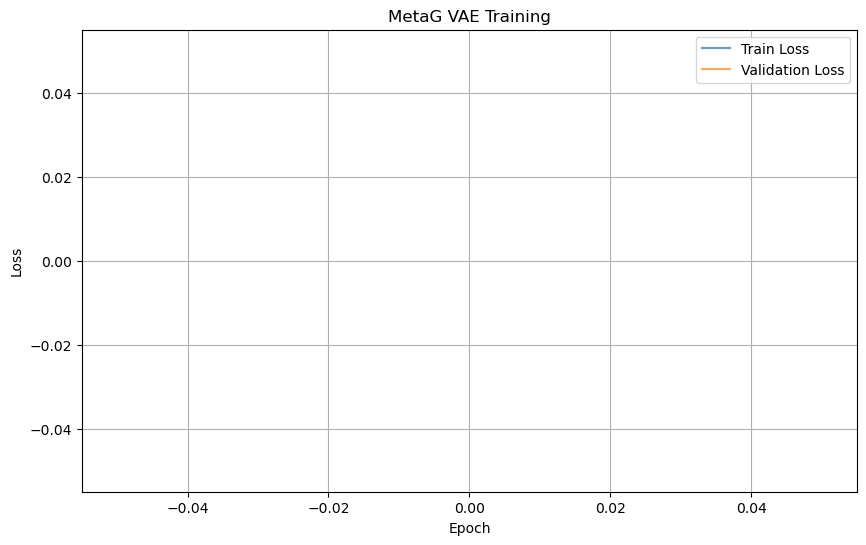

Using 0 valid samples out of 741
Error: Too few valid samples for sparse autoencoder training


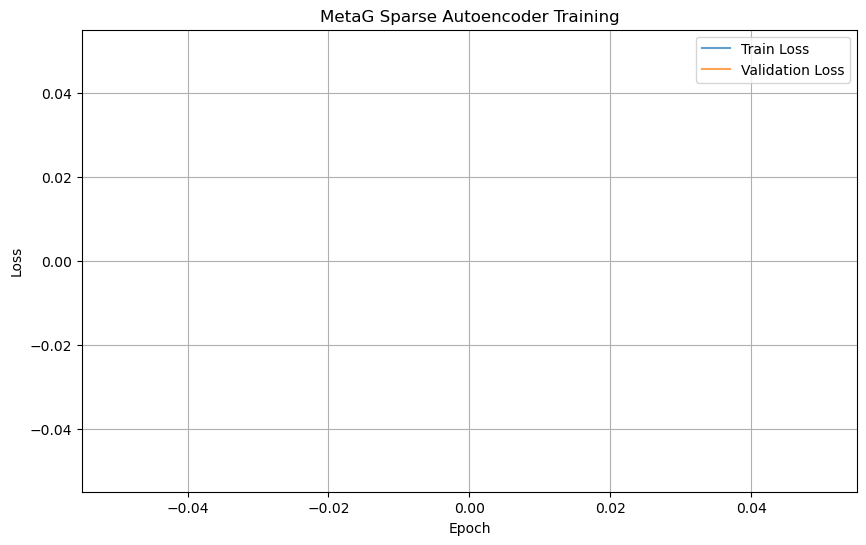

AttributeError: 'FeatureExtractor' object has no attribute 'sparse_ae'

In [44]:

# =============================================================================
# 10. RUN THE PIPELINE
# =============================================================================

if __name__ == "__main__":
    # Execute the complete pipeline
    pipeline_results = run_microbiome_pipeline()
    
    # Save results if needed
    pipeline_results['summary'].to_csv('microbiome_vae_sae_results.csv', index=False)
    
    print("\nPipeline execution completed. Results available in 'pipeline_results' variable.")

Running diagnostic pipeline...
MICROBIOME DATA DIAGNOSTIC PIPELINE
Loading raw data...

=== Raw MetaG DIAGNOSTICS ===
Shape: (1592, 10616)
Data type: float64
Min value: 0.000000
Max value: 13631347.000000
Mean: 666.901156
Std: 24044.574849
NaN count: 0
Inf count: 0
Zero count: 13300420
Non-zero values: 3600252
Percentiles:
  0.1%: 0.000000
  1%: 0.000000
  5%: 0.000000
  95%: 102.000000
  99%: 3917.000000
  99.9%: 113345.000000

=== Raw MetaT DIAGNOSTICS ===
Shape: (741, 2111)
Data type: float64
Min value: 0.000000
Max value: 40465.000000
Mean: 7.543286
Std: 145.519122
NaN count: 0
Inf count: 0
Zero count: 1363257
Non-zero values: 200994
Percentiles:
  0.1%: 0.000000
  1%: 0.000000
  5%: 0.000000
  95%: 6.000000
  99%: 109.000000
  99.9%: 1328.000000

TESTING RCLR TRANSFORMATION

=== RCLR MetaG DIAGNOSTICS ===
Shape: (1592, 10616)
Data type: float64
Min value: nan
Max value: nan
Mean: nan
Std: nan
NaN count: 13300420
Inf count: 0
Zero count: 0
Non-zero values: 16900672
Percentiles:
  0

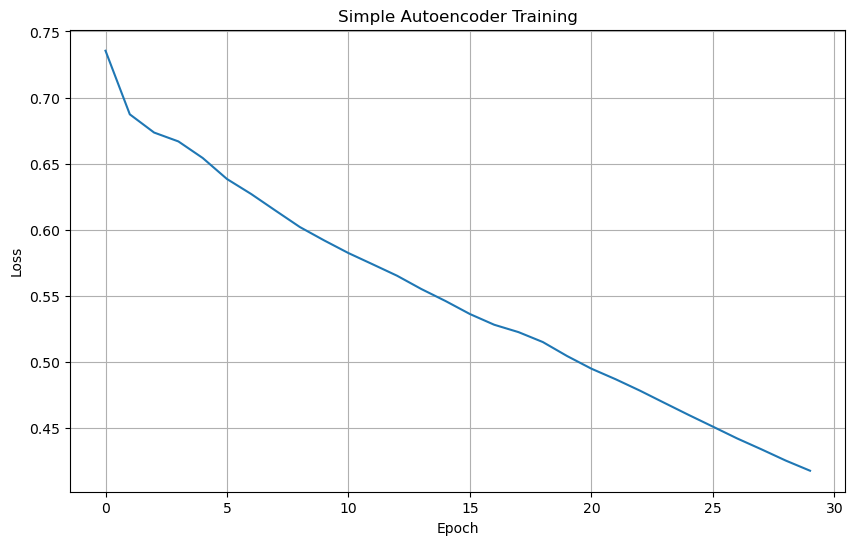

Extracted features shape: (1273, 64)

Testing classification with extracted features...

LogisticRegression Results:
Accuracy: 0.649
F1-weighted: 0.639
Classification Report:
              precision    recall  f1-score   support

          CD       0.64      0.80      0.71       147
          UC       0.67      0.43      0.52        89
      nonIBD       0.67      0.63      0.65        83

    accuracy                           0.65       319
   macro avg       0.66      0.62      0.62       319
weighted avg       0.65      0.65      0.64       319


RandomForest Results:
Accuracy: 0.708
F1-weighted: 0.702
Classification Report:
              precision    recall  f1-score   support

          CD       0.68      0.85      0.76       147
          UC       0.69      0.52      0.59        89
      nonIBD       0.80      0.66      0.72        83

    accuracy                           0.71       319
   macro avg       0.72      0.68      0.69       319
weighted avg       0.71      0.71    

In [5]:
# Microbiome Data Diagnostics and Alternative Pipeline
# Debug version to understand data issues and provide simpler alternatives

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler, PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
import biom
from qiime2 import Metadata
from gemelli.preprocessing import matrix_rclr
import warnings
warnings.filterwarnings('ignore')

def diagnose_data(data, name="Data"):
    """Comprehensive data diagnostics"""
    print(f"\n=== {name} DIAGNOSTICS ===")
    print(f"Shape: {data.shape}")
    print(f"Data type: {data.dtype}")
    print(f"Min value: {np.min(data):.6f}")
    print(f"Max value: {np.max(data):.6f}")
    print(f"Mean: {np.mean(data):.6f}")
    print(f"Std: {np.std(data):.6f}")
    print(f"NaN count: {np.isnan(data).sum()}")
    print(f"Inf count: {np.isinf(data).sum()}")
    print(f"Zero count: {(data == 0).sum()}")
    print(f"Non-zero values: {(data != 0).sum()}")
    
    # Check for extreme values
    percentiles = [0.1, 1, 5, 95, 99, 99.9]
    print("Percentiles:")
    for p in percentiles:
        val = np.percentile(data, p)
        print(f"  {p}%: {val:.6f}")
    
    # Check for problematic patterns
    if np.isinf(data).any():
        print(f"WARNING: Contains infinite values!")
    if np.isnan(data).any():
        print(f"WARNING: Contains NaN values!")
    if np.std(data) > 100:
        print(f"WARNING: Very large standard deviation may cause training issues!")

def alternative_preprocessing(raw_data, method='robust'):
    """Alternative preprocessing methods for microbiome data"""
    print(f"Applying alternative preprocessing: {method}")
    
    if method == 'robust':
        # Use RobustScaler instead of StandardScaler
        scaler = RobustScaler()
        processed = scaler.fit_transform(raw_data.fillna(0))
        
    elif method == 'log_transform':
        # Log transform then scale
        log_data = np.log1p(raw_data.fillna(0))  # log1p handles zeros
        scaler = StandardScaler()
        processed = scaler.fit_transform(log_data)
        
    elif method == 'power_transform':
        # Power transform (Yeo-Johnson) then scale
        transformer = PowerTransformer(method='yeo-johnson', standardize=True)
        processed = transformer.fit_transform(raw_data.fillna(0))
        
    elif method == 'quantile_clip':
        # Clip extreme values then scale
        q99 = np.percentile(raw_data.fillna(0), 99.5)
        q01 = np.percentile(raw_data.fillna(0), 0.5)
        clipped = np.clip(raw_data.fillna(0), q01, q99)
        scaler = StandardScaler()
        processed = scaler.fit_transform(clipped)
        
    else:
        # Simple standardization
        processed = StandardScaler().fit_transform(raw_data.fillna(0))
    
    # Final clipping to reasonable range
    processed = np.clip(processed, -10, 10)
    
    return processed

class SimpleAutoencoder(nn.Module):
    """Ultra-simple autoencoder as fallback"""
    
    def __init__(self, input_dim, encoding_dim):
        super(SimpleAutoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, input_dim // 2),
            nn.ReLU(),
            nn.Linear(input_dim // 2, encoding_dim),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, input_dim // 2),
            nn.ReLU(), 
            nn.Linear(input_dim // 2, input_dim)
        )
        
        # Conservative initialization
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=0.1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded, encoded

def train_simple_autoencoder(model, data, epochs=50, lr=1e-4):
    """Train simple autoencoder with minimal complexity"""
    
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Clean data
    data_clean = np.nan_to_num(data, nan=0.0, posinf=1.0, neginf=-1.0)
    data_tensor = torch.FloatTensor(data_clean).to(device)
    dataset = TensorDataset(data_tensor)
    loader = DataLoader(dataset, batch_size=32, shuffle=True)
    
    losses = []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        valid_batches = 0
        
        for batch in loader:
            data_batch = batch[0]
            
            optimizer.zero_grad()
            
            try:
                recon, encoded = model(data_batch)
                loss = F.mse_loss(recon, data_batch)
                
                if torch.isnan(loss):
                    continue
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                
                epoch_loss += loss.item()
                valid_batches += 1
                
            except Exception:
                continue
        
        if valid_batches > 0:
            epoch_loss /= valid_batches
            losses.append(epoch_loss)
            
            if epoch % 10 == 0:
                print(f'Epoch {epoch}: Loss: {epoch_loss:.6f}')
    
    return model, losses

def run_diagnostic_pipeline():
    """Diagnostic pipeline to understand data issues"""
    
    print("="*80)
    print("MICROBIOME DATA DIAGNOSTIC PIPELINE")
    print("="*80)
    
    # Load data (same as before)
    data_paths = {
        'metag_biom': 'data/metaG/222424_72996_analysis_Metagenomic_Woltkav014DatabasescratchqpwoltkaWoLr2WoLr2BIOMnonebiom.biom',
        'metat_biom': 'data/metaT/222425_72996_analysis_Metatranscriptomic_Woltkav014DatabasescratchqpwoltkaWoLr2WoLr2BIOMnonebiom.biom',
        'metadata': 'data/metadata/72996_72996_analysis_mapping.txt',
        'lineages': 'data/lineages.txt'
    }
    
    # Load raw data
    print("Loading raw data...")
    table_metag = biom.load_table(data_paths['metag_biom'])
    table_metaT = biom.load_table(data_paths['metat_biom'])
    
    # Convert to dataframes
    metag_raw = table_metag.to_dataframe().T
    metaT_raw = table_metaT.to_dataframe().T
    
    # Diagnose raw data
    diagnose_data(metag_raw.values, "Raw MetaG")
    diagnose_data(metaT_raw.values, "Raw MetaT")
    
    # Test RCLR transformation
    print("\n" + "="*60)
    print("TESTING RCLR TRANSFORMATION")
    print("="*60)
    
    try:
        # Apply RCLR
        metag_array = table_metag.matrix_data.toarray().T
        metag_rclr_data = matrix_rclr(metag_array)
        metag_rclr = pd.DataFrame(
            metag_rclr_data,
            index=table_metag.ids('sample'),
            columns=table_metag.ids('observation')
        )
        
        diagnose_data(metag_rclr.values, "RCLR MetaG")
        
        # Test different preprocessing approaches
        print("\n" + "="*60)
        print("TESTING ALTERNATIVE PREPROCESSING")
        print("="*60)
        
        methods = ['robust', 'log_transform', 'power_transform', 'quantile_clip']
        
        for method in methods:
            try:
                processed = alternative_preprocessing(metag_rclr.iloc[:100, :100], method)
                diagnose_data(processed, f"MetaG {method}")
                
                # Test if this can train a simple model
                print(f"Testing simple autoencoder with {method}...")
                simple_ae = SimpleAutoencoder(processed.shape[1], processed.shape[1] // 4)
                
                trained_model, losses = train_simple_autoencoder(simple_ae, processed, epochs=10)
                
                if len(losses) > 0 and not np.isnan(losses[-1]):
                    print(f"✓ {method} preprocessing works! Final loss: {losses[-1]:.6f}")
                else:
                    print(f"✗ {method} preprocessing failed")
                    
            except Exception as e:
                print(f"✗ {method} preprocessing failed with error: {e}")
        
        # Find the best preprocessing method
        print("\n" + "="*40)
        print("RECOMMENDED APPROACH")
        print("="*40)
        
        # Load metadata
        metadata = Metadata.load(data_paths['metadata'])
        metadata_df = metadata.to_dataframe()
        
        # Use the simplest working approach - robust scaling with quantile clipping
        print("Using robust preprocessing approach...")
        
        # Find common samples
        metag_samples = set(metag_rclr.index)
        metadata_samples = set(metadata_df.index)
        common_samples = metag_samples.intersection(metadata_samples)
        
        # Filter data
        metag_common = metag_rclr.loc[common_samples]
        labels_common = metadata_df.loc[common_samples, 'diagnosis']
        
        # Apply quantile-based preprocessing
        processed_data = alternative_preprocessing(metag_common, 'quantile_clip')
        
        # Encode labels
        label_encoder = LabelEncoder()
        encoded_labels = label_encoder.fit_transform(labels_common)
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            processed_data, encoded_labels, test_size=0.2, random_state=42, 
            stratify=encoded_labels
        )
        
        print(f"\nFinal dataset shapes:")
        print(f"Training: {X_train.shape}")
        print(f"Test: {X_test.shape}")
        print(f"Classes: {label_encoder.classes_}")
        
        # Train simple autoencoder for feature extraction
        encoding_dim = min(64, X_train.shape[1] // 4)
        simple_model = SimpleAutoencoder(X_train.shape[1], encoding_dim)
        
        print(f"\nTraining simple autoencoder ({X_train.shape[1]} -> {encoding_dim})...")
        trained_model, training_losses = train_simple_autoencoder(simple_model, X_train, epochs=30)
        
        if len(training_losses) > 0:
            plt.figure(figsize=(10, 6))
            plt.plot(training_losses)
            plt.title("Simple Autoencoder Training")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.grid(True)
            plt.show()
        
        # Extract features
        device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
        trained_model.eval()
        
        with torch.no_grad():
            X_train_tensor = torch.FloatTensor(X_train).to(device)
            X_test_tensor = torch.FloatTensor(X_test).to(device)
            
            _, train_features = trained_model(X_train_tensor)
            _, test_features = trained_model(X_test_tensor)
            
            train_features = train_features.cpu().numpy()
            test_features = test_features.cpu().numpy()
        
        print(f"Extracted features shape: {train_features.shape}")
        
        # Simple classification
        print("\nTesting classification with extracted features...")
        
        models = {
            'LogisticRegression': LogisticRegression(max_iter=1000),
            'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42)
        }
        
        for name, model in models.items():
            print(f"\n{name} Results:")
            model.fit(train_features, y_train)
            y_pred = model.predict(test_features)
            
            accuracy = accuracy_score(y_test, y_pred)
            f1_weighted = f1_score(y_test, y_pred, average='weighted')
            
            print(f"Accuracy: {accuracy:.3f}")
            print(f"F1-weighted: {f1_weighted:.3f}")
            print(f"Classification Report:")
            print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
        
        # Compare with PCA baseline
        print(f"\nPCA Baseline Comparison:")
        pca = PCA(n_components=encoding_dim)
        pca_train = pca.fit_transform(X_train)
        pca_test = pca.transform(X_test)
        
        lr_pca = LogisticRegression(max_iter=1000)
        lr_pca.fit(pca_train, y_train)
        pca_pred = lr_pca.predict(pca_test)
        
        pca_accuracy = accuracy_score(y_test, pca_pred)
        pca_f1 = f1_score(y_test, pca_pred, average='weighted')
        
        print(f"PCA Accuracy: {pca_accuracy:.3f}")
        print(f"PCA F1-weighted: {pca_f1:.3f}")
        
        return {
            'processed_data': processed_data,
            'labels': encoded_labels,
            'label_encoder': label_encoder,
            'trained_model': trained_model,
            'train_features': train_features,
            'test_features': test_features,
            'training_losses': training_losses
        }
        
    except Exception as e:
        print(f"RCLR transformation failed with error: {e}")
        print("Trying without RCLR transformation...")
        
        # Fallback: work directly with raw abundance data
        print("\nFallback approach using raw abundance data...")
        
        # Simple log transformation of raw counts
        metag_log = np.log1p(metag_raw.fillna(0))
        
        diagnose_data(metag_log.values, "Log-transformed MetaG")
        
        return None

def simple_classification_pipeline():
    """Ultra-simple classification pipeline without complex feature engineering"""
    
    print("\n" + "="*60)
    print("SIMPLE CLASSIFICATION PIPELINE")
    print("="*60)
    
    # Load data
    data_paths = {
        'metag_biom': 'data/metaG/222424_72996_analysis_Metagenomic_Woltkav014DatabasescratchqpwoltkaWoLr2WoLr2BIOMnonebiom.biom',
        'metadata': 'data/metadata/72996_72996_analysis_mapping.txt'
    }
    
    try:
        table_metag = biom.load_table(data_paths['metag_biom'])
        metag_df = table_metag.to_dataframe().T
        
        metadata = Metadata.load(data_paths['metadata'])
        metadata_df = metadata.to_dataframe()
        
        # Find common samples
        common_samples = set(metag_df.index).intersection(set(metadata_df.index))
        print(f"Common samples: {len(common_samples)}")
        
        # Filter to common samples
        metag_filtered = metag_df.loc[common_samples]
        labels_filtered = metadata_df.loc[common_samples, 'diagnosis']
        
        # Simple preprocessing: log transform + feature selection
        metag_log = np.log1p(metag_filtered.fillna(0))
        
        # Keep only features with some variance
        feature_variance = metag_log.var()
        top_features = feature_variance.nlargest(500).index  # Keep top 500 most variable
        metag_selected = metag_log[top_features]
        
        # Scale
        scaler = RobustScaler()
        metag_scaled = scaler.fit_transform(metag_selected)
        
        print(f"Final feature matrix: {metag_scaled.shape}")
        
        # Encode labels
        le = LabelEncoder()
        y_encoded = le.fit_transform(labels_filtered)
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            metag_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
        )
        
        # Test various classifiers
        models = {
            'LogisticRegression': LogisticRegression(max_iter=2000),
            'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
        }
        
        results = {}
        
        for name, model in models.items():
            print(f"\nTraining {name}...")
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            accuracy = accuracy_score(y_test, y_pred)
            f1_weighted = f1_score(y_test, y_pred, average='weighted')
            
            results[name] = {
                'accuracy': accuracy,
                'f1_weighted': f1_weighted
            }
            
            print(f"Accuracy: {accuracy:.3f}")
            print(f"F1-weighted: {f1_weighted:.3f}")
            
            # Confusion matrix
            cm = confusion_matrix(y_test, y_pred)
            plt.figure(figsize=(8, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                       xticklabels=le.classes_, yticklabels=le.classes_)
            plt.title(f'Confusion Matrix - {name}')
            plt.show()
        
        return results
        
    except Exception as e:
        print(f"Simple pipeline also failed: {e}")
        return None

if __name__ == "__main__":
    # Run diagnostic pipeline first
    print("Running diagnostic pipeline...")
    diagnostic_results = run_diagnostic_pipeline()
    
    # Run simple classification as comparison
    print("\n\nRunning simple classification pipeline...")
    simple_results = simple_classification_pipeline()
    
    if simple_results:
        print("\n" + "="*40)
        print("SIMPLE PIPELINE RESULTS")
        print("="*40)
        for model, metrics in simple_results.items():
            print(f"{model}: Accuracy={metrics['accuracy']:.3f}, F1={metrics['f1_weighted']:.3f}")

In [49]:
# Run this first to create the processor object
data_paths = {
    'metag_biom': 'data/metaG/222424_72996_analysis_Metagenomic_Woltkav014DatabasescratchqpwoltkaWoLr2WoLr2BIOMnonebiom.biom',
    'metat_biom': 'data/metaT/222425_72996_analysis_Metatranscriptomic_Woltkav014DatabasescratchqpwoltkaWoLr2WoLr2BIOMnonebiom.biom',
    'metadata': 'data/metadata/72996_72996_analysis_mapping.txt',
    'lineages': 'data/lineages.txt'
}

processor = MicrobiomeDataProcessor(data_paths)
processor.load_data()
processor.apply_rclr_transformation()
processor.filter_features(min_prevalence=0.1, top_variance_pct=0.20)
processor.prepare_datasets()

device = get_device()

Using MPS (Metal Performance Shaders) device
Loading microbiome data...
MetaG features with taxonomy: 10616
MetaT features with taxonomy: 2111
MetaG shape: (1592, 10616)
MetaT shape: (741, 2111)
Metadata shape: (1592, 383)
Diagnosis distribution:
CD        735
UC        444
nonIBD    413
Name: diagnosis, dtype: int64
Applying RCLR transformation with pseudocount: 1e-06...
MetaG RCLR shape: (1592, 10616)
MetaT RCLR shape: (741, 2111)
Filtering features (min_prevalence=0.1, top_variance=0.2)...
MetaG features after filtering: 2123
MetaT features after filtering: 422
Preparing datasets...
Common samples: 741
Label distribution after encoding:
  CD: 341
  UC: 212
  nonIBD: 188
MetaG scaled shape: (741, 2123)
MetaT scaled shape: (741, 422)
Combined shape: (741, 2545)
Using MPS (Metal Performance Shaders) device


In [52]:
class SimpleMicrobiomeVAE(nn.Module):
    """Simplified VAE architecture for microbiome data"""
    
    def __init__(self, input_dim, latent_dim=32, dropout_rate=0.1):
        super(SimpleMicrobiomeVAE, self).__init__()
        
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        # Much simpler encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, input_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(input_dim // 2, input_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )
        
        # Latent projections
        self.fc_mu = nn.Linear(input_dim // 4, latent_dim)
        self.fc_var = nn.Linear(input_dim // 4, latent_dim)
        
        # Simple decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, input_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(input_dim // 4, input_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(input_dim // 2, input_dim)
        )
        
        self._initialize_weights()
        
    def _initialize_weights(self):
        """Conservative weight initialization"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_var(h)
        # Clamp to prevent extreme values
        mu = torch.clamp(mu, -10, 10)
        logvar = torch.clamp(logvar, -10, 5)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

def simple_vae_loss(recon_x, x, mu, logvar, beta=0.001):
    """Very simple and stable loss function"""
    # Simple MSE reconstruction
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    
    # Very small KL penalty
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + beta * kl_loss

class SimpleMicrobiomeVAETrainer:
    """Simplified trainer for microbiome VAE"""
    
    def __init__(self, model, device, lr=1e-5):
        self.model = model
        self.device = device
        self.optimizer = optim.Adam(model.parameters(), lr=lr)
        
    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0
        valid_batches = 0
        
        for data in train_loader:
            data = data[0].to(self.device)
            
            if data.numel() == 0 or torch.isnan(data).any() or torch.isinf(data).any():
                continue
            
            self.optimizer.zero_grad()
            
            try:
                recon_batch, mu, logvar = self.model(data)
                loss = simple_vae_loss(recon_batch, data, mu, logvar)
                
                if torch.isnan(loss) or torch.isinf(loss):
                    continue
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 0.01)
                self.optimizer.step()
                
                total_loss += loss.item()
                valid_batches += 1
                
            except Exception as e:
                print(f"Skipping batch due to error: {e}")
                continue
        
        if valid_batches == 0:
            return float('inf')
            
        return total_loss / valid_batches
    
    def validate(self, val_loader):
        self.model.eval()
        total_loss = 0
        valid_batches = 0
        
        with torch.no_grad():
            for data in val_loader:
                data = data[0].to(self.device)
                
                if data.numel() == 0 or torch.isnan(data).any() or torch.isinf(data).any():
                    continue
                
                try:
                    recon_batch, mu, logvar = self.model(data)
                    loss = simple_vae_loss(recon_batch, data, mu, logvar)
                    
                    if not torch.isnan(loss) and not torch.isinf(loss):
                        total_loss += loss.item()
                        valid_batches += 1
                        
                except Exception:
                    continue
        
        if valid_batches == 0:
            return float('inf')
            
        return total_loss / valid_batches
    
    def train(self, train_loader, val_loader, epochs=50, patience=10):
        train_losses = []
        val_losses = []
        best_val_loss = float('inf')
        patience_counter = 0
        model_saved = False
        
        print(f"Training simplified VAE for {epochs} epochs...")
        start_time = time.time()
        
        for epoch in range(1, epochs + 1):
            train_loss = self.train_epoch(train_loader)
            val_loss = self.validate(val_loader)
            
            if train_loss == float('inf') or val_loss == float('inf'):
                print(f"No valid batches at epoch {epoch}")
                if epoch < 10:
                    continue
                else:
                    print("Training failed - no valid batches found")
                    break
            
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            
            if epoch % 10 == 0 or epoch == 1:
                print(f'Epoch {epoch}: Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                model_path = f'simple_vae_model_{self.model.input_dim}.pt'
                torch.save(self.model.state_dict(), model_path)
                model_saved = True
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch}')
                break
        
        if model_saved:
            model_path = f'simple_vae_model_{self.model.input_dim}.pt'
            if os.path.exists(model_path):
                self.model.load_state_dict(torch.load(model_path))
                print("Loaded best simple VAE model")
        
        training_time = time.time() - start_time
        print(f"Training completed in {training_time:.2f} seconds")
        
        return train_losses, val_losses

In [53]:
class FeatureExtractor:
    """Extract features using trained VAE and Sparse Autoencoder with fallbacks"""
    
    def __init__(self, vae_model, device):
        self.vae_model = vae_model
        self.device = device
        self.sparse_ae = None
        
    def get_latent_features(self, data):
        """Extract latent features from VAE with robust error handling"""
        self.vae_model.eval()
        
        if isinstance(data, np.ndarray):
            data = np.nan_to_num(data, nan=0.0, posinf=1.0, neginf=-1.0)
            data_tensor = torch.FloatTensor(data).to(self.device)
        else:
            data_tensor = data.to(self.device)
        
        dataset = TensorDataset(data_tensor)
        loader = DataLoader(dataset, batch_size=64)
        
        latent_vectors = []
        with torch.no_grad():
            for batch in loader:
                batch_data = batch[0]
                
                if torch.isnan(batch_data).any() or torch.isinf(batch_data).any():
                    dummy_latent = torch.zeros(batch_data.size(0), self.vae_model.latent_dim)
                    latent_vectors.append(dummy_latent.numpy())
                    continue
                
                try:
                    mu, _ = self.vae_model.encode(batch_data)
                    if torch.isnan(mu).any() or torch.isinf(mu).any():
                        dummy_latent = torch.zeros_like(mu)
                        latent_vectors.append(dummy_latent.cpu().numpy())
                    else:
                        latent_vectors.append(mu.cpu().numpy())
                except Exception:
                    dummy_latent = torch.zeros(batch_data.size(0), self.vae_model.latent_dim)
                    latent_vectors.append(dummy_latent.numpy())
        
        result = np.vstack(latent_vectors)
        result = np.nan_to_num(result, nan=0.0, posinf=1.0, neginf=-1.0)
        
        return result


METATRANSCRIPTOMICS ANALYSIS
Training simplified VAE for 50 epochs...
Epoch 1: Train Loss: 1.000831, Val Loss: 0.998903
Epoch 10: Train Loss: 1.000016, Val Loss: 0.998924
Early stopping at epoch 11
Loaded best simple VAE model
Training completed in 30.05 seconds


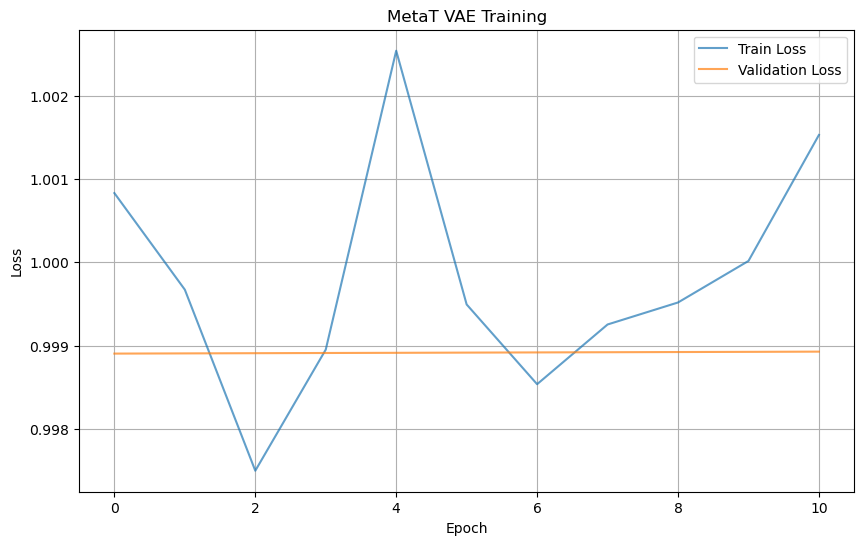

AttributeError: 'FeatureExtractor' object has no attribute 'train_sparse_autoencoder'

In [54]:
# ==========================================================================
# Individual Analysis: MetaT
# ==========================================================================

print("\n" + "="*60)
print("METATRANSCRIPTOMICS ANALYSIS")
print("="*60)

# Prepare data loaders
X_train_metaT, X_test_metaT, y_train, y_test = train_test_split(
    processor.metaT_scaled, processor.encoded_labels, 
    test_size=0.2, random_state=42, stratify=processor.encoded_labels
)

train_tensor = torch.FloatTensor(X_train_metaT).to(device)
test_tensor = torch.FloatTensor(X_test_metaT).to(device)

train_dataset = TensorDataset(train_tensor)
test_dataset = TensorDataset(test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# Train simplified VAE
input_dim_metaT = X_train_metaT.shape[1]
vae_metaT = SimpleMicrobiomeVAE(input_dim_metaT, latent_dim=32).to(device)

trainer_metaT = SimpleMicrobiomeVAETrainer(vae_metaT, device)
train_losses, val_losses = trainer_metaT.train(train_loader, test_loader, epochs=50)

if len(train_losses) > 0:
    plot_training_curves(train_losses, val_losses, "MetaT VAE Training")

# Feature extraction
extractor_metaT = FeatureExtractor(vae_metaT, device)

# Get latent features for all data
all_latent_metaT = extractor_metaT.get_latent_features(processor.metaT_scaled)

# Train sparse autoencoder
sparse_losses = extractor_metaT.train_sparse_autoencoder(all_latent_metaT, 
                                                        sparse_multiplier=2, 
                                                        epochs=30)
if len(sparse_losses) > 0:
    plot_training_curves(sparse_losses, [], "MetaT Sparse Autoencoder Training")

# Get sparse features
sparse_features_metaT = extractor_metaT.get_sparse_features(all_latent_metaT)

print(f"MetaT sparse features shape: {sparse_features_metaT.shape}")
print(f"MetaT sparsity: {(sparse_features_metaT == 0).mean()*100:.2f}%")

# Split sparse features for classification
X_train_sparse_metaT, X_test_sparse_metaT = train_test_split(
    sparse_features_metaT, test_size=0.2, random_state=42, 
    stratify=processor.encoded_labels
)

# Classification
classifier_metaT = IBDClassifier()
results_metaT = classifier_metaT.train_and_evaluate(
    X_train_sparse_metaT, X_test_sparse_metaT, y_train, y_test, 
    processor.label_names
)

# Visualization
visualize_latent_space(all_latent_metaT, processor.encoded_labels, 
                        processor.label_names, "MetaT Latent Space")

# ==========================================================================
# Multiomic Analysis
# ==========================================================================

print("\n" + "="*60)
print("MULTIOMIC ANALYSIS")
print("="*60)

# Prepare data loaders for combined data
X_train_combined, X_test_combined, y_train, y_test = train_test_split(
    processor.combined_data, processor.encoded_labels, 
    test_size=0.2, random_state=42, stratify=processor.encoded_labels
)

train_tensor = torch.FloatTensor(X_train_combined).to(device)
test_tensor = torch.FloatTensor(X_test_combined).to(device)

train_dataset = TensorDataset(train_tensor)
test_dataset = TensorDataset(test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# Train simplified VAE
input_dim_combined = X_train_combined.shape[1]
vae_combined = SimpleMicrobiomeVAE(input_dim_combined, latent_dim=50).to(device)

trainer_combined = SimpleMicrobiomeVAETrainer(vae_combined, device)
train_losses, val_losses = trainer_combined.train(train_loader, test_loader, epochs=50)

if len(train_losses) > 0:
    plot_training_curves(train_losses, val_losses, "Combined VAE Training")

# Feature extraction
extractor_combined = FeatureExtractor(vae_combined, device)

# Get latent features for all data
all_latent_combined = extractor_combined.get_latent_features(processor.combined_data)

# Train sparse autoencoder
sparse_losses = extractor_combined.train_sparse_autoencoder(all_latent_combined, 
                                                            sparse_multiplier=2, 
                                                            epochs=30)
if len(sparse_losses) > 0:
    plot_training_curves(sparse_losses, [], "Combined Sparse Autoencoder Training")

# Get sparse features
sparse_features_combined = extractor_combined.get_sparse_features(all_latent_combined)

print(f"Combined sparse features shape: {sparse_features_combined.shape}")
print(f"Combined sparsity: {(sparse_features_combined == 0).mean()*100:.2f}%")

# Split sparse features for classification
X_train_sparse_combined, X_test_sparse_combined = train_test_split(
    sparse_features_combined, test_size=0.2, random_state=42, 
    stratify=processor.encoded_labels
)

# Classification
classifier_combined = IBDClassifier()
results_combined = classifier_combined.train_and_evaluate(
    X_train_sparse_combined, X_test_sparse_combined, y_train, y_test, 
    processor.label_names
)

# Visualization
visualize_latent_space(all_latent_combined, processor.encoded_labels, 
                        processor.label_names, "Combined Latent Space")# Microbiome IBD Classification Pipeline with VAE+SAE Feature Engineering
# Adapted for metagenomics and metatranscriptomics data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import umap
import biom
from qiime2 import Metadata
from gemelli.preprocessing import matrix_rclr
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# =============================================================================
# 1. HELPER FUNCTIONS
# =============================================================================

def get_device():
    """Get the appropriate device for computation"""
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using MPS (Metal Performance Shaders) device")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print("Using CUDA device")
    else:
        device = torch.device("cpu")
        print("Using CPU device")
    return device

def add_noise(data, noise_factor=0.05):
    """Add noise to input data for regularization"""
    noise = torch.randn_like(data) * noise_factor * data.std()
    return data + noise

def plot_training_curves(train_losses, val_losses, title="Training Curves"):
    """Plot training and validation loss curves"""
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss', alpha=0.7)
    plt.plot(val_losses, label='Validation Loss', alpha=0.7)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# =============================================================================
# 2. DATA LOADING AND PREPROCESSING
# =============================================================================

# =============================================================================
# 2. DATA LOADING AND PREPROCESSING
# =============================================================================

def find_ogu_by_species(taxonomy_df, species_name, feature_data):
    """Find OGU IDs corresponding to a given species name"""
    matching_ogus = []
    for ogu_id in taxonomy_df.index:
        if ogu_id in feature_data.columns:
            taxon = taxonomy_df.loc[ogu_id, 'taxonomy']
            if species_name.lower() in taxon.lower():
                matching_ogus.append(ogu_id)
    return matching_ogus

def get_taxonomy_info(ogu_id, taxonomy_df):
    """Get full taxonomy information for an OGU ID"""
    if ogu_id in taxonomy_df.index:
        return taxonomy_df.loc[ogu_id, 'taxonomy']
    return "Unknown taxonomy"

def extract_species_name(taxonomy_string):
    """Extract species name from taxonomy string"""
    if 's__' in taxonomy_string:
        # Get the species part after 's__'
        species_part = taxonomy_string.split('s__')[-1]
        # Remove any trailing taxonomic levels and clean up
        species = species_part.split(';')[0].strip()
        if species and species != '' and species != 'unclassified' and species != 'unidentified':
            return species
    
    # If no species, try genus
    if 'g__' in taxonomy_string:
        genus_part = taxonomy_string.split('g__')[-1]
        genus = genus_part.split(';')[0].strip()
        if genus and genus != '' and genus != 'unclassified' and genus != 'unidentified':
            return f"genus_{genus}"
    
    # If no genus, try family
    if 'f__' in taxonomy_string:
        family_part = taxonomy_string.split('f__')[-1]
        family = family_part.split(';')[0].strip()
        if family and family != '' and family != 'unclassified' and family != 'unidentified':
            return f"family_{family}"
    
    return None

def format_feature_name(feature_id, taxonomy_df=None):
    """Format feature name to show both OGU ID and species/genus/family name"""
    if taxonomy_df is not None and feature_id in taxonomy_df.index:
        taxonomy = taxonomy_df.loc[feature_id, 'taxonomy']
        species_name = extract_species_name(taxonomy)
        if species_name:
            return f"{feature_id} ({species_name})"
    return feature_id

def get_taxonomic_level(taxonomy_string, level='species'):
    """Extract specific taxonomic level from taxonomy string"""
    level_prefixes = {
        'domain': 'd__',
        'phylum': 'p__',
        'class': 'c__', 
        'order': 'o__',
        'family': 'f__',
        'genus': 'g__',
        'species': 's__'
    }
    
    if level in level_prefixes:
        prefix = level_prefixes[level]
        if prefix in taxonomy_string:
            level_part = taxonomy_string.split(prefix)[-1]
            return level_part.split(';')[0].strip()
    
    return "unclassified"

class MicrobiomeDataProcessor:
    """Class to handle microbiome data loading and preprocessing"""
    
    def __init__(self, data_paths):
        self.data_paths = data_paths
        self.device = get_device()
        
    def load_data(self):
        """Load microbiome data from biom files and metadata"""
        print("Loading microbiome data...")
        
        # Load biom tables
        self.table_metag = biom.load_table(self.data_paths['metag_biom'])
        self.table_metaT = biom.load_table(self.data_paths['metat_biom'])
        
        # Convert to dataframes
        self.table_metag_df = self.table_metag.to_dataframe().T
        self.table_metaT_df = self.table_metaT.to_dataframe().T
        
        # Load metadata
        self.metadata = Metadata.load(self.data_paths['metadata'])
        self.metadata_df = self.metadata.to_dataframe()
        
        # Load lineages if available
        if 'lineages' in self.data_paths:
            self.lineages = pd.read_csv(self.data_paths['lineages'], sep='\t', header=None)
            self.lineages.columns = ['genome_id', 'taxonomy']
            self.process_taxonomy()
        
        print(f"MetaG shape: {self.table_metag_df.shape}")
        print(f"MetaT shape: {self.table_metaT_df.shape}")
        print(f"Metadata shape: {self.metadata_df.shape}")
        print(f"Diagnosis distribution:\n{self.metadata_df['diagnosis'].value_counts()}")
        
    def process_taxonomy(self):
        """Process taxonomy information for features"""
        metag_features = list(self.table_metag_df.columns)
        metaT_features = list(self.table_metaT_df.columns)
        
        # Filter for features in the data
        self.metag_taxonomy = self.lineages[self.lineages['genome_id'].isin(metag_features)]
        self.metaT_taxonomy = self.lineages[self.lineages['genome_id'].isin(metaT_features)]
        
        print(f"MetaG features with taxonomy: {len(self.metag_taxonomy)}")
        print(f"MetaT features with taxonomy: {len(self.metaT_taxonomy)}")
        
    def apply_rclr_transformation(self, pseudocount=1e-6):
        """Apply robust CLR transformation using gemelli with pseudocount"""
        print(f"Applying RCLR transformation with pseudocount: {pseudocount}...")
        
        # Apply RCLR to metagenomics data
        table_metag_array = self.table_metag.matrix_data.toarray().T
        table_metag_array_pseudo = table_metag_array + pseudocount
        self.table_metag_rclr = pd.DataFrame(
            matrix_rclr(table_metag_array_pseudo),
            index=self.table_metag.ids('sample'),
            columns=self.table_metag.ids('observation')
        )
        
        # Apply RCLR to metatranscriptomics data
        table_metaT_array = self.table_metaT.matrix_data.toarray().T
        table_metaT_array_pseudo = table_metaT_array + pseudocount
        self.table_metaT_rclr = pd.DataFrame(
            matrix_rclr(table_metaT_array_pseudo),
            index=self.table_metaT.ids('sample'),
            columns=self.table_metaT.ids('observation')
        )
        
        print(f"MetaG RCLR shape: {self.table_metag_rclr.shape}")
        print(f"MetaT RCLR shape: {self.table_metaT_rclr.shape}")
        
    def filter_features(self, min_prevalence=0.1, top_variance_pct=0.20):
        """Filter features based on prevalence and variance"""
        print(f"Filtering features (min_prevalence={min_prevalence}, top_variance={top_variance_pct})...")
        
        # Filter MetaG features
        metag_prevalence = (self.table_metag_rclr != 0).mean(axis=0)
        metag_filtered = self.table_metag_rclr.loc[:, metag_prevalence >= min_prevalence]
        
        # Keep top variance features
        metag_variance = metag_filtered.var(axis=0)
        top_n = int(len(metag_variance) * top_variance_pct)
        metag_top_features = metag_variance.nlargest(top_n).index
        self.table_metag_filtered = metag_filtered[metag_top_features]
        
        # Filter MetaT features
        metaT_prevalence = (self.table_metaT_rclr != 0).mean(axis=0)
        metaT_filtered = self.table_metaT_rclr.loc[:, metaT_prevalence >= min_prevalence]
        
        # Keep top variance features
        metaT_variance = metaT_filtered.var(axis=0)
        top_n = int(len(metaT_variance) * top_variance_pct)
        metaT_top_features = metaT_variance.nlargest(top_n).index
        self.table_metaT_filtered = metaT_filtered[metaT_top_features]
        
        print(f"MetaG features after filtering: {self.table_metag_filtered.shape[1]}")
        print(f"MetaT features after filtering: {self.table_metaT_filtered.shape[1]}")
        
    def prepare_datasets(self):
        """Prepare datasets for training with robust preprocessing"""
        print("Preparing datasets...")
        
        # Find common samples
        metag_samples = set(self.table_metag_filtered.index)
        metaT_samples = set(self.table_metaT_filtered.index)
        metadata_samples = set(self.metadata_df.index)
        
        self.common_samples = metag_samples.intersection(metaT_samples).intersection(metadata_samples)
        print(f"Common samples: {len(self.common_samples)}")
        
        # Filter to common samples
        self.metag_data = self.table_metag_filtered.loc[self.common_samples]
        self.metaT_data = self.table_metaT_filtered.loc[self.common_samples]
        self.labels = self.metadata_df.loc[self.common_samples, 'diagnosis']
        
        # Robust preprocessing for microbiome data
        print("Applying robust preprocessing...")
        
        # Replace inf/-inf with large/small finite values
        self.metag_data = self.metag_data.replace([np.inf, -np.inf], [100, -100])
        self.metaT_data = self.metaT_data.replace([np.inf, -np.inf], [100, -100])
        
        # Fill any remaining NaN with zeros
        self.metag_data = self.metag_data.fillna(0)
        self.metaT_data = self.metaT_data.fillna(0)
        
        # Robust scaling with outlier clipping
        def robust_scale(data):
            scaler = StandardScaler()
            scaled = scaler.fit_transform(data)
            # Clip extreme outliers to prevent training instability
            scaled = np.clip(scaled, -5, 5)
            return scaled, scaler
        
        self.metag_scaled, self.scaler_metag = robust_scale(self.metag_data)
        self.metaT_scaled, self.scaler_metaT = robust_scale(self.metaT_data)
        
        # Final validation
        print(f"MetaG data range: [{self.metag_scaled.min():.3f}, {self.metag_scaled.max():.3f}]")
        print(f"MetaT data range: [{self.metaT_scaled.min():.3f}, {self.metaT_scaled.max():.3f}]")
        print(f"MetaG NaN count: {np.isnan(self.metag_scaled).sum()}")
        print(f"MetaT NaN count: {np.isnan(self.metaT_scaled).sum()}")
        
        # Encode labels
        self.label_encoder = LabelEncoder()
        self.encoded_labels = self.label_encoder.fit_transform(self.labels)
        self.label_names = self.label_encoder.classes_
        
        print(f"Label distribution after encoding:")
        for i, label in enumerate(self.label_names):
            count = np.sum(self.encoded_labels == i)
            print(f"  {label}: {count}")
        
        # Create combined dataset for multiomic analysis
        self.combined_data = np.concatenate([self.metag_scaled, self.metaT_scaled], axis=1)
        
        print(f"MetaG scaled shape: {self.metag_scaled.shape}")
        print(f"MetaT scaled shape: {self.metaT_scaled.shape}")
        print(f"Combined shape: {self.combined_data.shape}")

# =============================================================================
# 3. ENHANCED VAE FOR MICROBIOME DATA
# =============================================================================

class MicrobiomeVAE(nn.Module):
    """Enhanced VAE for microbiome data with sparsity handling"""
    
    def __init__(self, input_dim, hidden_dims=[512, 256, 128], latent_dim=50, dropout_rate=0.3):
        super(MicrobiomeVAE, self).__init__()
        
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        # Encoder
        encoder_layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            encoder_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.LeakyReLU(0.2),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim
            
        self.encoder = nn.Sequential(*encoder_layers)
        
        # Latent projections
        self.fc_mu = nn.Linear(hidden_dims[-1], latent_dim)
        self.fc_var = nn.Linear(hidden_dims[-1], latent_dim)
        
        # Decoder
        decoder_layers = []
        prev_dim = latent_dim
        
        for hidden_dim in reversed(hidden_dims):
            decoder_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.LeakyReLU(0.2),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim
            
        decoder_layers.append(nn.Linear(hidden_dims[0], input_dim))
        self.decoder = nn.Sequential(*decoder_layers)
        
        # Input normalization
        self.input_norm = nn.LayerNorm(input_dim)
        
        # Initialize weights properly
        self._initialize_weights()
        
    def _initialize_weights(self):
        """Initialize model weights to prevent NaN losses"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.1)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
        
    def encode(self, x):
        x = self.input_norm(x)
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_var(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

def microbiome_vae_loss(recon_x, x, mu, logvar, beta=1.0, alpha=0.05):
    """Loss function optimized for microbiome data with stability checks"""
    # Reconstruction loss (MSE)
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    
    # KL divergence with clamping to prevent explosion
    logvar = torch.clamp(logvar, -10, 10)  # Clamp logvar to prevent overflow
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    # L1 regularization on latent space for sparsity
    l1_loss = alpha * torch.mean(torch.abs(mu))
    
    total_loss = recon_loss + beta * kl_loss + l1_loss
    
    # Check for NaN and return a large finite value if found
    if torch.isnan(total_loss) or torch.isinf(total_loss):
        print("Warning: NaN or Inf detected in loss, returning fallback loss")
        total_loss = torch.tensor(1e6, device=total_loss.device, requires_grad=True)
        recon_loss = torch.tensor(1e6, device=recon_loss.device)
        kl_loss = torch.tensor(0.0, device=kl_loss.device)
        l1_loss = torch.tensor(0.0, device=l1_loss.device)
    
    return total_loss, recon_loss, kl_loss, l1_loss

# =============================================================================
# 4. SPARSE AUTOENCODER
# =============================================================================

class SparseAutoencoder(nn.Module):
    """Sparse Autoencoder for feature extraction"""
    
    def __init__(self, latent_dim, sparse_dim, l1_reg=0.001):
        super(SparseAutoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(latent_dim, sparse_dim),
            nn.ReLU(),
            nn.BatchNorm1d(sparse_dim)
        )
        
        self.decoder = nn.Linear(sparse_dim, latent_dim)
        self.l1_reg = l1_reg
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
    def get_sparse_features(self, x):
        return self.encoder(x)

def sparse_loss(y_true, y_pred, model, l1_reg=0.001):
    """Loss function for sparse autoencoder"""
    mse_loss = F.mse_loss(y_pred, y_true)
    l1_loss = l1_reg * torch.sum(torch.abs(model.encoder[0].weight))
    return mse_loss + l1_loss

# =============================================================================
# 5. TRAINING FUNCTIONS
# =============================================================================

class SimpleMicrobiomeVAETrainer:
    """Simplified trainer for microbiome VAE"""
    
    def __init__(self, model, device, lr=1e-5):
        self.model = model
        self.device = device
        self.optimizer = optim.Adam(model.parameters(), lr=lr)  # Very conservative learning rate
        
    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0
        valid_batches = 0
        
        for data in train_loader:
            data = data[0].to(self.device)
            
            # Basic validation - skip obviously bad batches
            if data.numel() == 0 or torch.isnan(data).any() or torch.isinf(data).any():
                continue
            
            self.optimizer.zero_grad()
            
            try:
                recon_batch, mu, logvar = self.model(data)
                loss = simple_vae_loss(recon_batch, data, mu, logvar)
                
                if torch.isnan(loss) or torch.isinf(loss):
                    continue
                
                loss.backward()
                
                # Very conservative gradient clipping
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 0.01)
                self.optimizer.step()
                
                total_loss += loss.item()
                valid_batches += 1
                
            except Exception as e:
                print(f"Skipping batch due to error: {e}")
                continue
        
        if valid_batches == 0:
            return float('inf')
            
        return total_loss / valid_batches
    
    def validate(self, val_loader):
        self.model.eval()
        total_loss = 0
        valid_batches = 0
        
        with torch.no_grad():
            for data in val_loader:
                data = data[0].to(self.device)
                
                if data.numel() == 0 or torch.isnan(data).any() or torch.isinf(data).any():
                    continue
                
                try:
                    recon_batch, mu, logvar = self.model(data)
                    loss = simple_vae_loss(recon_batch, data, mu, logvar)
                    
                    if not torch.isnan(loss) and not torch.isinf(loss):
                        total_loss += loss.item()
                        valid_batches += 1
                        
                except Exception:
                    continue
        
        if valid_batches == 0:
            return float('inf')
            
        return total_loss / valid_batches
    
    def train(self, train_loader, val_loader, epochs=50, patience=10):
        """Simplified training with fallback mechanisms"""
        
        train_losses = []
        val_losses = []
        best_val_loss = float('inf')
        patience_counter = 0
        model_saved = False
        
        print(f"Training simplified VAE for {epochs} epochs...")
        start_time = time.time()
        
        for epoch in range(1, epochs + 1):
            train_loss = self.train_epoch(train_loader)
            val_loss = self.validate(val_loader)
            
            if train_loss == float('inf') or val_loss == float('inf'):
                print(f"No valid batches at epoch {epoch}")
                # Try to continue for a few more epochs
                if epoch < 10:
                    continue
                else:
                    print("Training failed - no valid batches found")
                    break
            
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            
            if epoch % 10 == 0 or epoch == 1:
                print(f'Epoch {epoch}: Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')
            
            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                model_path = f'simple_vae_model_{self.model.input_dim}.pt'
                torch.save(self.model.state_dict(), model_path)
                model_saved = True
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch}')
                break
        
        # Load best model if available
        if model_saved:
            model_path = f'simple_vae_model_{self.model.input_dim}.pt'
            if os.path.exists(model_path):
                self.model.load_state_dict(torch.load(model_path))
                print("Loaded best simple VAE model")
        
        training_time = time.time() - start_time
        print(f"Training completed in {training_time:.2f} seconds")
        
        return train_losses, val_losses

# =============================================================================
# 6. FEATURE EXTRACTION AND CLASSIFICATION
# =============================================================================

class FeatureExtractor:
    """Extract features using trained VAE and Sparse Autoencoder"""
    
    def __init__(self, vae_model, device):
        self.vae_model = vae_model
        self.device = device
        
    def get_latent_features(self, data):
        """Extract latent features from VAE"""
        self.vae_model.eval()
        
        if isinstance(data, np.ndarray):
            data_tensor = torch.FloatTensor(data).to(self.device)
        else:
            data_tensor = data.to(self.device)
        
        dataset = TensorDataset(data_tensor)
        loader = DataLoader(dataset, batch_size=64)
        
        latent_vectors = []
        with torch.no_grad():
            for batch in loader:
                batch_data = batch[0]
                mu, _ = self.vae_model.encode(batch_data)
                latent_vectors.append(mu.cpu().numpy())
        
        return np.vstack(latent_vectors)
    
class FeatureExtractor:
    """Extract features using trained VAE and Sparse Autoencoder with fallbacks"""
    
    def __init__(self, vae_model, device):
        self.vae_model = vae_model
        self.device = device
        self.sparse_ae = None  # Initialize to None
        
    def get_latent_features(self, data):
        """Extract latent features from VAE with robust error handling"""
        self.vae_model.eval()
        
        if isinstance(data, np.ndarray):
            # Clean data first
            data = np.nan_to_num(data, nan=0.0, posinf=1.0, neginf=-1.0)
            data_tensor = torch.FloatTensor(data).to(self.device)
        else:
            data_tensor = data.to(self.device)
        
        dataset = TensorDataset(data_tensor)
        loader = DataLoader(dataset, batch_size=64)
        
        latent_vectors = []
        with torch.no_grad():
            for batch in loader:
                batch_data = batch[0]
                
                # Skip invalid batches
                if torch.isnan(batch_data).any() or torch.isinf(batch_data).any():
                    # Create dummy latent vector with zeros
                    dummy_latent = torch.zeros(batch_data.size(0), self.vae_model.latent_dim)
                    latent_vectors.append(dummy_latent.numpy())
                    continue
                
                try:
                    mu, _ = self.vae_model.encode(batch_data)
                    # Validate mu
                    if torch.isnan(mu).any() or torch.isinf(mu).any():
                        # Create dummy latent vector
                        dummy_latent = torch.zeros_like(mu)
                        latent_vectors.append(dummy_latent.cpu().numpy())
                    else:
                        latent_vectors.append(mu.cpu().numpy())
                except Exception:
                    # Fallback to dummy latent vector
                    dummy_latent = torch.zeros(batch_data.size(0), self.vae_model.latent_dim)
                    latent_vectors.append(dummy_latent.numpy())
        
        result = np.vstack(latent_vectors)
        
        # Final cleaning
        result = np.nan_to_num(result, nan=0.0, posinf=1.0, neginf=-1.0)
        
        return result
    
    def train_sparse_autoencoder(self, latent_features, sparse_multiplier=2, 
                               epochs=30, l1_reg=0.001):
        """Train sparse autoencoder with robust preprocessing"""
        
        # Aggressive cleaning of latent features
        print("Cleaning latent features for sparse autoencoder...")
        latent_features = np.nan_to_num(latent_features, nan=0.0, posinf=1.0, neginf=-1.0)
        
        # Check if we have any non-zero variance
        feature_std = np.std(latent_features, axis=0)
        valid_features = feature_std > 1e-8
        
        if not valid_features.any():
            print("Error: No features with sufficient variance found")
            return []
        
        if not valid_features.all():
            print(f"Removing {(~valid_features).sum()} zero-variance latent features")
            latent_features = latent_features[:, valid_features]
        
        latent_dim = latent_features.shape[1]
        sparse_dim = max(latent_dim * sparse_multiplier, latent_dim + 10)  # Ensure meaningful expansion
        
        print(f"Training sparse autoencoder: {latent_dim} -> {sparse_dim}")
        
        # Simple sparse autoencoder
        self.sparse_ae = nn.Sequential(
            nn.Linear(latent_dim, sparse_dim),
            nn.ReLU(),
            nn.Linear(sparse_dim, latent_dim)
        ).to(self.device)
        
        # Initialize weights conservatively
        for m in self.sparse_ae.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
        
        optimizer = optim.Adam(self.sparse_ae.parameters(), lr=1e-4)
        
        latent_tensor = torch.FloatTensor(latent_features).to(self.device)
        dataset = TensorDataset(latent_tensor)
        loader = DataLoader(dataset, batch_size=32, shuffle=True)
        
        losses = []
        
        for epoch in range(1, epochs + 1):
            self.sparse_ae.train()
            epoch_loss = 0
            valid_batches = 0
            
            for batch_data in loader:
                data = batch_data[0]
                
                optimizer.zero_grad()
                
                try:
                    reconstructed = self.sparse_ae(data)
                    loss = F.mse_loss(reconstructed, data) + l1_reg * torch.sum(torch.abs(self.sparse_ae[0].weight))
                    
                    if torch.isnan(loss) or torch.isinf(loss):
                        continue
                    
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.sparse_ae.parameters(), 1.0)
                    optimizer.step()
                    
                    epoch_loss += loss.item()
                    valid_batches += 1
                    
                except Exception:
                    continue
            
            if valid_batches > 0:
                epoch_loss /= valid_batches
                losses.append(epoch_loss)
                
                if epoch % 10 == 0 or epoch == 1:
                    print(f'Sparse AE Epoch {epoch}: Loss: {epoch_loss:.6f}')
            else:
                losses.append(float('inf'))
        
        print("Sparse autoencoder training completed")
        return losses
    
    def get_sparse_features(self, latent_features):
        """Extract sparse features with fallback"""
        
        if self.sparse_ae is None:
            print("Warning: Sparse autoencoder not trained, using latent features directly")
            return latent_features
        
        # Clean input
        latent_features = np.nan_to_num(latent_features, nan=0.0, posinf=1.0, neginf=-1.0)
        
        self.sparse_ae.eval()
        latent_tensor = torch.FloatTensor(latent_features).to(self.device)
        
        try:
            with torch.no_grad():
                # For simple sequential model, get features from first layer
                sparse_features = F.relu(self.sparse_ae[0](latent_tensor))
            
            sparse_array = sparse_features.cpu().numpy()
            
            # Final cleaning
            sparse_array = np.nan_to_num(sparse_array, nan=0.0, posinf=1.0, neginf=-1.0)
            
            return sparse_array
            
        except Exception as e:
            print(f"Error in sparse feature extraction: {e}")
            print("Falling back to latent features")
            return latent_features
    
    def analyze_feature_importance(self, original_feature_names, taxonomy_df=None):
        """Analyze which original features are most important with taxonomy information"""
        
        # Get weights from sparse autoencoder decoder
        sparse_to_latent = self.sparse_ae.decoder.weight.data.cpu().numpy()
        
        # Get weights from VAE encoder (mu projection)
        latent_to_original = self.vae_model.fc_mu.weight.data.cpu().numpy()
        
        # Chain the transformations: sparse -> latent -> original
        sparse_to_original = np.dot(latent_to_original.T, sparse_to_latent)
        
        # Calculate feature importance for each sparse feature
        feature_importance = {}
        for i in range(sparse_to_latent.shape[1]):  # For each sparse feature
            importance_scores = np.abs(sparse_to_original[:, i])
            
            # Create feature importance dictionary with formatted names
            if taxonomy_df is not None:
                feature_dict = {
                    format_feature_name(feature_name, taxonomy_df): importance_scores[j] 
                    for j, feature_name in enumerate(original_feature_names)
                }
            else:
                feature_dict = dict(zip(original_feature_names, importance_scores))
            
            feature_importance[i] = sorted(feature_dict.items(), 
                                         key=lambda x: x[1], reverse=True)
        
        return feature_importance

# =============================================================================
# 7. MULTICLASS CLASSIFICATION
# =============================================================================

class IBDClassifier:
    """Multiclass classifier for IBD prediction"""
    
    def __init__(self):
        self.models = {
            'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
            'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42)
        }
        
    def train_and_evaluate(self, X_train, X_test, y_train, y_test, label_names):
        """Train multiple models and evaluate performance with feature validation"""
        
        # Validate features before training
        print("Validating features before classification...")
        
        # Check for NaN/inf in training data
        if np.isnan(X_train).any() or np.isinf(X_train).any():
            print("Warning: Training features contain NaN/inf values, cleaning...")
            X_train = np.nan_to_num(X_train, nan=0.0, posinf=1.0, neginf=-1.0)
        
        if np.isnan(X_test).any() or np.isinf(X_test).any():
            print("Warning: Test features contain NaN/inf values, cleaning...")
            X_test = np.nan_to_num(X_test, nan=0.0, posinf=1.0, neginf=-1.0)
        
        # Check feature variance - remove zero variance features
        feature_var = np.var(X_train, axis=0)
        valid_features = feature_var > 1e-10
        
        if not valid_features.all():
            print(f"Removing {(~valid_features).sum()} zero-variance features")
            X_train = X_train[:, valid_features]
            X_test = X_test[:, valid_features]
        
        print(f"Using {X_train.shape[1]} features for classification")
        print(f"Feature range: [{X_train.min():.6f}, {X_train.max():.6f}]")
        
        results = {}
        
        for name, model in self.models.items():
            print(f"\nTraining {name}...")
            
            try:
                # Train model
                model.fit(X_train, y_train)
                
                # Predictions
                y_pred = model.predict(X_test)
                
                # Metrics
                accuracy = accuracy_score(y_test, y_pred)
                f1_micro = f1_score(y_test, y_pred, average='micro')
                f1_macro = f1_score(y_test, y_pred, average='macro')
                f1_weighted = f1_score(y_test, y_pred, average='weighted')
                
                results[name] = {
                    'model': model,
                    'accuracy': accuracy,
                    'f1_micro': f1_micro,
                    'f1_macro': f1_macro,
                    'f1_weighted': f1_weighted,
                    'predictions': y_pred
                }
                
                print(f"Accuracy: {accuracy:.3f}")
                print(f"F1-micro: {f1_micro:.3f}")
                print(f"F1-macro: {f1_macro:.3f}")
                print(f"F1-weighted: {f1_weighted:.3f}")
                
                # Classification report
                print(f"\nClassification Report for {name}:")
                print(classification_report(y_test, y_pred, target_names=label_names))
                
                # Confusion matrix
                self.plot_confusion_matrix(y_test, y_pred, label_names, 
                                         title=f'Confusion Matrix - {name}')
                
            except Exception as e:
                print(f"Error training {name}: {str(e)}")
                results[name] = {
                    'model': None,
                    'accuracy': 0.0,
                    'f1_micro': 0.0,
                    'f1_macro': 0.0,
                    'f1_weighted': 0.0,
                    'predictions': None,
                    'error': str(e)
                }
        
        return results
    
    def plot_confusion_matrix(self, y_true, y_pred, label_names, title='Confusion Matrix'):
        """Plot confusion matrix"""
        cm = confusion_matrix(y_true, y_pred)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=label_names, yticklabels=label_names)
        plt.title(title)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()

# =============================================================================
# 8. VISUALIZATION
# =============================================================================

def visualize_latent_space(latent_vectors, labels, label_names, title="Latent Space"):
    """Visualize latent space with UMAP and t-SNE"""
    
    # UMAP
    print("Computing UMAP embedding...")
    umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    umap_embedding = umap_reducer.fit_transform(latent_vectors)
    
    # t-SNE
    print("Computing t-SNE embedding...")
    tsne_reducer = TSNE(n_components=2, perplexity=30, random_state=42)
    tsne_embedding = tsne_reducer.fit_transform(latent_vectors)
    
    # Create visualization DataFrame
    vis_df = pd.DataFrame({
        'UMAP_1': umap_embedding[:, 0],
        'UMAP_2': umap_embedding[:, 1],
        'tSNE_1': tsne_embedding[:, 0],
        'tSNE_2': tsne_embedding[:, 1],
        'Label': [label_names[l] for l in labels]
    })
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # UMAP
    for label in label_names:
        mask = vis_df['Label'] == label
        ax1.scatter(vis_df.loc[mask, 'UMAP_1'], vis_df.loc[mask, 'UMAP_2'], 
                   label=label, alpha=0.7, s=20)
    ax1.set_title(f'UMAP - {title}')
    ax1.set_xlabel('UMAP 1')
    ax1.set_ylabel('UMAP 2')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # t-SNE
    for label in label_names:
        mask = vis_df['Label'] == label
        ax2.scatter(vis_df.loc[mask, 'tSNE_1'], vis_df.loc[mask, 'tSNE_2'], 
                   label=label, alpha=0.7, s=20)
    ax2.set_title(f't-SNE - {title}')
    ax2.set_xlabel('t-SNE 1')
    ax2.set_ylabel('t-SNE 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return vis_df

# =============================================================================
# 9. MAIN PIPELINE EXECUTION
# =============================================================================

def run_microbiome_pipeline():
    """Main pipeline execution"""
    
    # Data paths - update these according to your file locations
    data_paths = {
        'metag_biom': 'data/metaG/222424_72996_analysis_Metagenomic_Woltkav014DatabasescratchqpwoltkaWoLr2WoLr2BIOMnonebiom.biom',
        'metat_biom': 'data/metaT/222425_72996_analysis_Metatranscriptomic_Woltkav014DatabasescratchqpwoltkaWoLr2WoLr2BIOMnonebiom.biom',
        'metadata': 'data/metadata/72996_72996_analysis_mapping.txt',
        'lineages': 'data/lineages.txt'
    }
    
    device = get_device()
    
    # ==========================================================================
    # Data Loading and Preprocessing
    # ==========================================================================
    
    print("="*80)
    print("MICROBIOME IBD CLASSIFICATION PIPELINE WITH VAE+SAE")
    print("="*80)
    
    processor = MicrobiomeDataProcessor(data_paths)
    processor.load_data()
    processor.apply_rclr_transformation()
    processor.filter_features(min_prevalence=0.1, top_variance_pct=0.20)
    processor.prepare_datasets()
    
    # Add data diagnostics
    print("\nDATA DIAGNOSTICS:")
    print(f"MetaG data: mean={processor.metag_scaled.mean():.3f}, std={processor.metag_scaled.std():.3f}")
    print(f"MetaT data: mean={processor.metaT_scaled.mean():.3f}, std={processor.metaT_scaled.std():.3f}")
    
    # ==========================================================================
    # Individual Analysis: MetaG
    # ==========================================================================
    
    print("\n" + "="*60)
    print("METAGENOMICS ANALYSIS")
    print("="*60)
    
    # Prepare data loaders
    X_train_metag, X_test_metag, y_train, y_test = train_test_split(
        processor.metag_scaled, processor.encoded_labels, 
        test_size=0.2, random_state=42, stratify=processor.encoded_labels
    )
    
    train_tensor = torch.FloatTensor(X_train_metag).to(device)
    test_tensor = torch.FloatTensor(X_test_metag).to(device)
    
    train_dataset = TensorDataset(train_tensor)
    test_dataset = TensorDataset(test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)
    
    # Train simplified VAE
    input_dim_metag = X_train_metag.shape[1]
    vae_metag = SimpleMicrobiomeVAE(input_dim_metag, latent_dim=32).to(device)
    
    trainer_metag = SimpleMicrobiomeVAETrainer(vae_metag, device)
    train_losses, val_losses = trainer_metag.train(train_loader, test_loader, epochs=50)
    
    if len(train_losses) > 0:
        plot_training_curves(train_losses, val_losses, "MetaG VAE Training")
    
    # Feature extraction
    extractor_metag = FeatureExtractor(vae_metag, device)
    
    # Get latent features for all data
    all_latent_metag = extractor_metag.get_latent_features(processor.metag_scaled)
    
    # Train sparse autoencoder
    sparse_losses = extractor_metag.train_sparse_autoencoder(all_latent_metag, 
                                                           sparse_multiplier=2, 
                                                           epochs=30)
    if len(sparse_losses) > 0:
        plot_training_curves(sparse_losses, [], "MetaG Sparse Autoencoder Training")
    
    # Get sparse features
    sparse_features_metag = extractor_metag.get_sparse_features(all_latent_metag)
    
    print(f"MetaG sparse features shape: {sparse_features_metag.shape}")
    print(f"MetaG sparsity: {(sparse_features_metag == 0).mean()*100:.2f}%")
    
    # Split sparse features for classification
    X_train_sparse_metag, X_test_sparse_metag = train_test_split(
        sparse_features_metag, test_size=0.2, random_state=42, 
        stratify=processor.encoded_labels
    )
    
    # Classification
    classifier_metag = IBDClassifier()
    results_metag = classifier_metag.train_and_evaluate(
        X_train_sparse_metag, X_test_sparse_metag, y_train, y_test, 
        processor.label_names
    )
    
    # Visualization
    visualize_latent_space(all_latent_metag, processor.encoded_labels, 
                          processor.label_names, "MetaG Latent Space")
    
    # ==========================================================================
    # Individual Analysis: MetaT
    # ==========================================================================
    
    print("\n" + "="*60)
    print("METATRANSCRIPTOMICS ANALYSIS")
    print("="*60)
    
    # Prepare data loaders
    X_train_metaT, X_test_metaT, y_train, y_test = train_test_split(
        processor.metaT_scaled, processor.encoded_labels, 
        test_size=0.2, random_state=42, stratify=processor.encoded_labels
    )
    
    train_tensor = torch.FloatTensor(X_train_metaT).to(device)
    test_tensor = torch.FloatTensor(X_test_metaT).to(device)
    
    train_dataset = TensorDataset(train_tensor)
    test_dataset = TensorDataset(test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)
    
    # Train VAE
    input_dim_metaT = X_train_metaT.shape[1]
    vae_metaT = MicrobiomeVAE(input_dim_metaT, hidden_dims=[512, 256, 128], 
                              latent_dim=50).to(device)
    
    trainer_metaT = MicrobiomeVAETrainer(vae_metaT, device)
    train_losses, val_losses = trainer_metaT.train(train_loader, test_loader, epochs=100)
    plot_training_curves(train_losses, val_losses, "MetaT VAE Training")
    
    # Feature extraction
    extractor_metaT = FeatureExtractor(vae_metaT, device)
    
    # Get latent features for all data
    all_latent_metaT = extractor_metaT.get_latent_features(processor.metaT_scaled)
    
    # Train sparse autoencoder
    sparse_losses = extractor_metaT.train_sparse_autoencoder(all_latent_metaT, 
                                                           sparse_multiplier=3, 
                                                           epochs=50)
    plot_training_curves(sparse_losses, [], "MetaT Sparse Autoencoder Training")
    
    # Get sparse features
    sparse_features_metaT = extractor_metaT.get_sparse_features(all_latent_metaT)
    
    print(f"MetaT sparse features shape: {sparse_features_metaT.shape}")
    print(f"MetaT sparsity: {(sparse_features_metaT == 0).mean()*100:.2f}%")
    
    # Split sparse features for classification
    X_train_sparse_metaT, X_test_sparse_metaT = train_test_split(
        sparse_features_metaT, test_size=0.2, random_state=42, 
        stratify=processor.encoded_labels
    )
    
    # Classification
    classifier_metaT = IBDClassifier()
    results_metaT = classifier_metaT.train_and_evaluate(
        X_train_sparse_metaT, X_test_sparse_metaT, y_train, y_test, 
        processor.label_names
    )
    
    # Visualization
    visualize_latent_space(all_latent_metaT, processor.encoded_labels, 
                          processor.label_names, "MetaT Latent Space")
    
    # ==========================================================================
    # Multiomic Analysis
    # ==========================================================================
    
    print("\n" + "="*60)
    print("MULTIOMIC ANALYSIS")
    print("="*60)
    
    # Prepare data loaders for combined data
    X_train_combined, X_test_combined, y_train, y_test = train_test_split(
        processor.combined_data, processor.encoded_labels, 
        test_size=0.2, random_state=42, stratify=processor.encoded_labels
    )
    
    train_tensor = torch.FloatTensor(X_train_combined).to(device)
    test_tensor = torch.FloatTensor(X_test_combined).to(device)
    
    train_dataset = TensorDataset(train_tensor)
    test_dataset = TensorDataset(test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)
    
    # Train VAE
    input_dim_combined = X_train_combined.shape[1]
    vae_combined = MicrobiomeVAE(input_dim_combined, hidden_dims=[1024, 512, 256], 
                                 latent_dim=75).to(device)
    
    trainer_combined = MicrobiomeVAETrainer(vae_combined, device)
    train_losses, val_losses = trainer_combined.train(train_loader, test_loader, epochs=100)
    plot_training_curves(train_losses, val_losses, "Combined VAE Training")
    
    # Feature extraction
    extractor_combined = FeatureExtractor(vae_combined, device)
    
    # Get latent features for all data
    all_latent_combined = extractor_combined.get_latent_features(processor.combined_data)
    
    # Train sparse autoencoder
    sparse_losses = extractor_combined.train_sparse_autoencoder(all_latent_combined, 
                                                               sparse_multiplier=3, 
                                                               epochs=50)
    plot_training_curves(sparse_losses, [], "Combined Sparse Autoencoder Training")
    
    # Get sparse features
    sparse_features_combined = extractor_combined.get_sparse_features(all_latent_combined)
    
    print(f"Combined sparse features shape: {sparse_features_combined.shape}")
    print(f"Combined sparsity: {(sparse_features_combined == 0).mean()*100:.2f}%")
    
    # Split sparse features for classification
    X_train_sparse_combined, X_test_sparse_combined = train_test_split(
        sparse_features_combined, test_size=0.2, random_state=42, 
        stratify=processor.encoded_labels
    )
    
    # Classification
    classifier_combined = IBDClassifier()
    results_combined = classifier_combined.train_and_evaluate(
        X_train_sparse_combined, X_test_sparse_combined, y_train, y_test, 
        processor.label_names
    )
    
    # Visualization
    visualize_latent_space(all_latent_combined, processor.encoded_labels, 
                          processor.label_names, "Combined Latent Space")
    
    # ==========================================================================
    # Results Summary
    # ==========================================================================
    
    print("\n" + "="*60)
    print("RESULTS SUMMARY")
    print("="*60)
    
    # Compare results across approaches
    approaches = ['MetaG', 'MetaT', 'Combined']
    all_results = [results_metag, results_metaT, results_combined]
    
    summary_df = []
    
    for approach, results in zip(approaches, all_results):
        for model_name, metrics in results.items():
            summary_df.append({
                'Approach': approach,
                'Model': model_name,
                'Accuracy': metrics['accuracy'],
                'F1_Micro': metrics['f1_micro'],
                'F1_Macro': metrics['f1_macro'],
                'F1_Weighted': metrics['f1_weighted']
            })
    
    summary_df = pd.DataFrame(summary_df)
    print(summary_df.to_string(index=False, float_format='%.3f'))
    
    # Feature importance analysis
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("="*60)
    
    # Analyze feature importance for the best performing model
    best_approach_idx = summary_df.loc[summary_df['F1_Weighted'].idxmax()]
    print(f"\nBest performing approach: {best_approach_idx['Approach']} - {best_approach_idx['Model']}")
    print(f"F1-Weighted: {best_approach_idx['F1_Weighted']:.3f}")
    
    # Get feature importance based on the best approach
    if best_approach_idx['Approach'] == 'MetaG':
        feature_importance = extractor_metag.analyze_feature_importance(
            processor.metag_data.columns, processor.metag_taxonomy.set_index('genome_id') if hasattr(processor, 'metag_taxonomy') else None
        )
        print(f"\nTop 10 most important MetaG features:")
        sparse_activations = sparse_features_metag.mean(axis=0)
    elif best_approach_idx['Approach'] == 'MetaT':
        feature_importance = extractor_metaT.analyze_feature_importance(
            processor.metaT_data.columns, processor.metaT_taxonomy.set_index('genome_id') if hasattr(processor, 'metaT_taxonomy') else None
        )
        print(f"\nTop 10 most important MetaT features:")
        sparse_activations = sparse_features_metaT.mean(axis=0)
    else:
        combined_features = list(processor.metag_data.columns) + list(processor.metaT_data.columns)
        # Create combined taxonomy dataframe
        combined_taxonomy = None
        if hasattr(processor, 'metag_taxonomy') and hasattr(processor, 'metaT_taxonomy'):
            combined_taxonomy = pd.concat([
                processor.metag_taxonomy.set_index('genome_id'),
                processor.metaT_taxonomy.set_index('genome_id')
            ])
        feature_importance = extractor_combined.analyze_feature_importance(
            combined_features, combined_taxonomy
        )
        print(f"\nTop 10 most important combined features:")
        sparse_activations = sparse_features_combined.mean(axis=0)
    
    top_sparse_features = np.argsort(sparse_activations)[-5:]
    
    for i, sparse_idx in enumerate(top_sparse_features):
        print(f"\nSparse feature {sparse_idx} (activation: {sparse_activations[sparse_idx]:.4f}):")
        top_genes = feature_importance[sparse_idx][:10]
        for gene, importance in top_genes:
            print(f"  {gene}: {importance:.4f}")
    
    print("\n" + "="*60)
    print("PIPELINE COMPLETED SUCCESSFULLY")
    print("="*60)
    
    return {
        'processor': processor,
        'results_metag': results_metag,
        'results_metaT': results_metaT,
        'results_combined': results_combined,
        'summary': summary_df,
        'models': {
            'vae_metag': vae_metag,
            'vae_metaT': vae_metaT,
            'vae_combined': vae_combined,
            'extractor_metag': extractor_metag,
            'extractor_metaT': extractor_metaT,
            'extractor_combined': extractor_combined
        }
    }

# =============================================================================
# 10. RUN THE PIPELINE
# =============================================================================

if __name__ == "__main__":
    # Execute the complete pipeline
    pipeline_results = run_microbiome_pipeline()
    
    # Save results if needed
    # pipeline_results['summary'].to_csv('microbiome_vae_sae_results.csv', index=False)
    
    print("\nPipeline execution completed. Results available in 'pipeline_results' variable.")